In [ ]:
# ============================================================
# Title:
# A Unified Multimodal Explainable Generative AI Framework
# for Multi-Class Neurological Disease Detection Using
# Federated Deep Learning, Vision Transformers,
# Graph Neural Networks, and Statistical Feature Fusion
# ============================================================

# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q kagglehub timm torchmetrics seaborn gradio

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import time
import cv2
import timm
import torch
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.7 MB/s eta 0:00:00


In [ ]:
# ============================================================
# DOWNLOAD DATASET
# ============================================================

import kagglehub

path = kagglehub.dataset_download(
    "alifatahi/multi-class-neurological-disorder-mcnd-dataset"
)

print("Dataset Path:", path)

# ============================================================
# DATA DIRECTORY
# ============================================================

data_dir = path

# ============================================================
# IMAGE TRANSFORMATIONS
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

# ============================================================
# LOAD DATASET
# ============================================================

dataset = datasets.ImageFolder(data_dir, transform=transform)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

100%|██████████| 503M/503M [00:23<00:00, 22.2MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/alifatahi/multi-class-neurological-disorder-mcnd-dataset/versions/1
Classes: ['AD_MildDemented', 'AD_ModerateDemented', 'AD_VeryMildDemented', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

dataset = datasets.ImageFolder(data_dir, transform=transform)

class_names = dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Classes: ['AD_MildDemented', 'AD_ModerateDemented', 'AD_VeryMildDemented', 'BT_glioma', 'BT_meningioma', 'BT_pituitary', 'MS', 'Normal']


In [ ]:

# ============================================================
# VISION TRANSFORMER MODEL
# ============================================================

model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

# ============================================================
# LOSS AND OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:

# ============================================================
# TRAINING
# ============================================================

epochs = 10

train_acc = []
val_acc = []

train_loss = []
val_loss = []

epoch_time = []

start_total = time.time()

for epoch in range(epochs):

    start = time.time()

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_acc.append(train_accuracy)

    train_loss.append(running_loss / len(train_loader))

    # =====================================================
    # VALIDATION
    # =====================================================

    model.eval()

    correct = 0
    total = 0

    running_val_loss = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    val_accuracy = 100 * correct / total

    val_acc.append(val_accuracy)

    val_loss.append(running_val_loss / len(test_loader))

    end = time.time()

    epoch_time.append(end - start)

    print(f"\nEpoch [{epoch+1}/{epochs}] | Train Accuracy: {train_accuracy:.2f} | Validation Accuracy: {val_accuracy:.2f}")


100%|██████████| 410/410 [09:14<00:00,  1.35s/it]



Epoch [1/10] | Train Accuracy: 77.82 | Validation Accuracy: 78.81


100%|██████████| 410/410 [09:12<00:00,  1.35s/it]



Epoch [2/10] | Train Accuracy: 81.20 | Validation Accuracy: 81.95


100%|██████████| 410/410 [09:12<00:00,  1.35s/it]


...


Epoch [8/10] | Train Accuracy: 92.52 | Validation Accuracy: 91.95


100%|██████████| 410/410 [09:13<00:00,  1.35s/it]



Epoch [9/10] | Train Accuracy: 93.70 | Validation Accuracy: 91.34


100%|██████████| 410/410 [09:13<00:00,  1.35s/it]



Epoch [10/10] | Train Accuracy: 94.18 | Validation Accuracy: 94.15


In [ ]:
model.eval()



y_true = []
y_pred = []
y_prob = []
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

    loss = criterion(outputs, labels)

    running_val_loss += loss.item()

    probs = torch.softmax(outputs, dim=1)

    _, predicted = torch.max(outputs.data, 1)



    y_true.extend(labels.cpu().numpy())
    y_pred.extend(predicted.cpu().numpy())
    y_prob.extend(probs.cpu().numpy())
# ============================================================
# FINAL METRICS
# ============================================================

print(classification_report(y_true,y_pred,target_names=class_names))



                     precision    recall  f1-score   support

    AD_MildDemented       0.93      0.87      0.90       166
AD_ModerateDemented       1.00      1.00      1.00         9
AD_VeryMildDemented       0.89      0.88      0.89       460
          BT_glioma       0.99      0.98      0.98       330
      BT_meningioma       0.98      0.96      0.97       301
       BT_pituitary       0.98      0.99      0.98       356
                 MS       0.99      0.83      0.90       295
             Normal       0.93      0.97      0.95      1363

           accuracy                           0.94      3280
          macro avg       0.96      0.94      0.95      3280
       weighted avg       0.94      0.94      0.94      3280



In [ ]:
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')



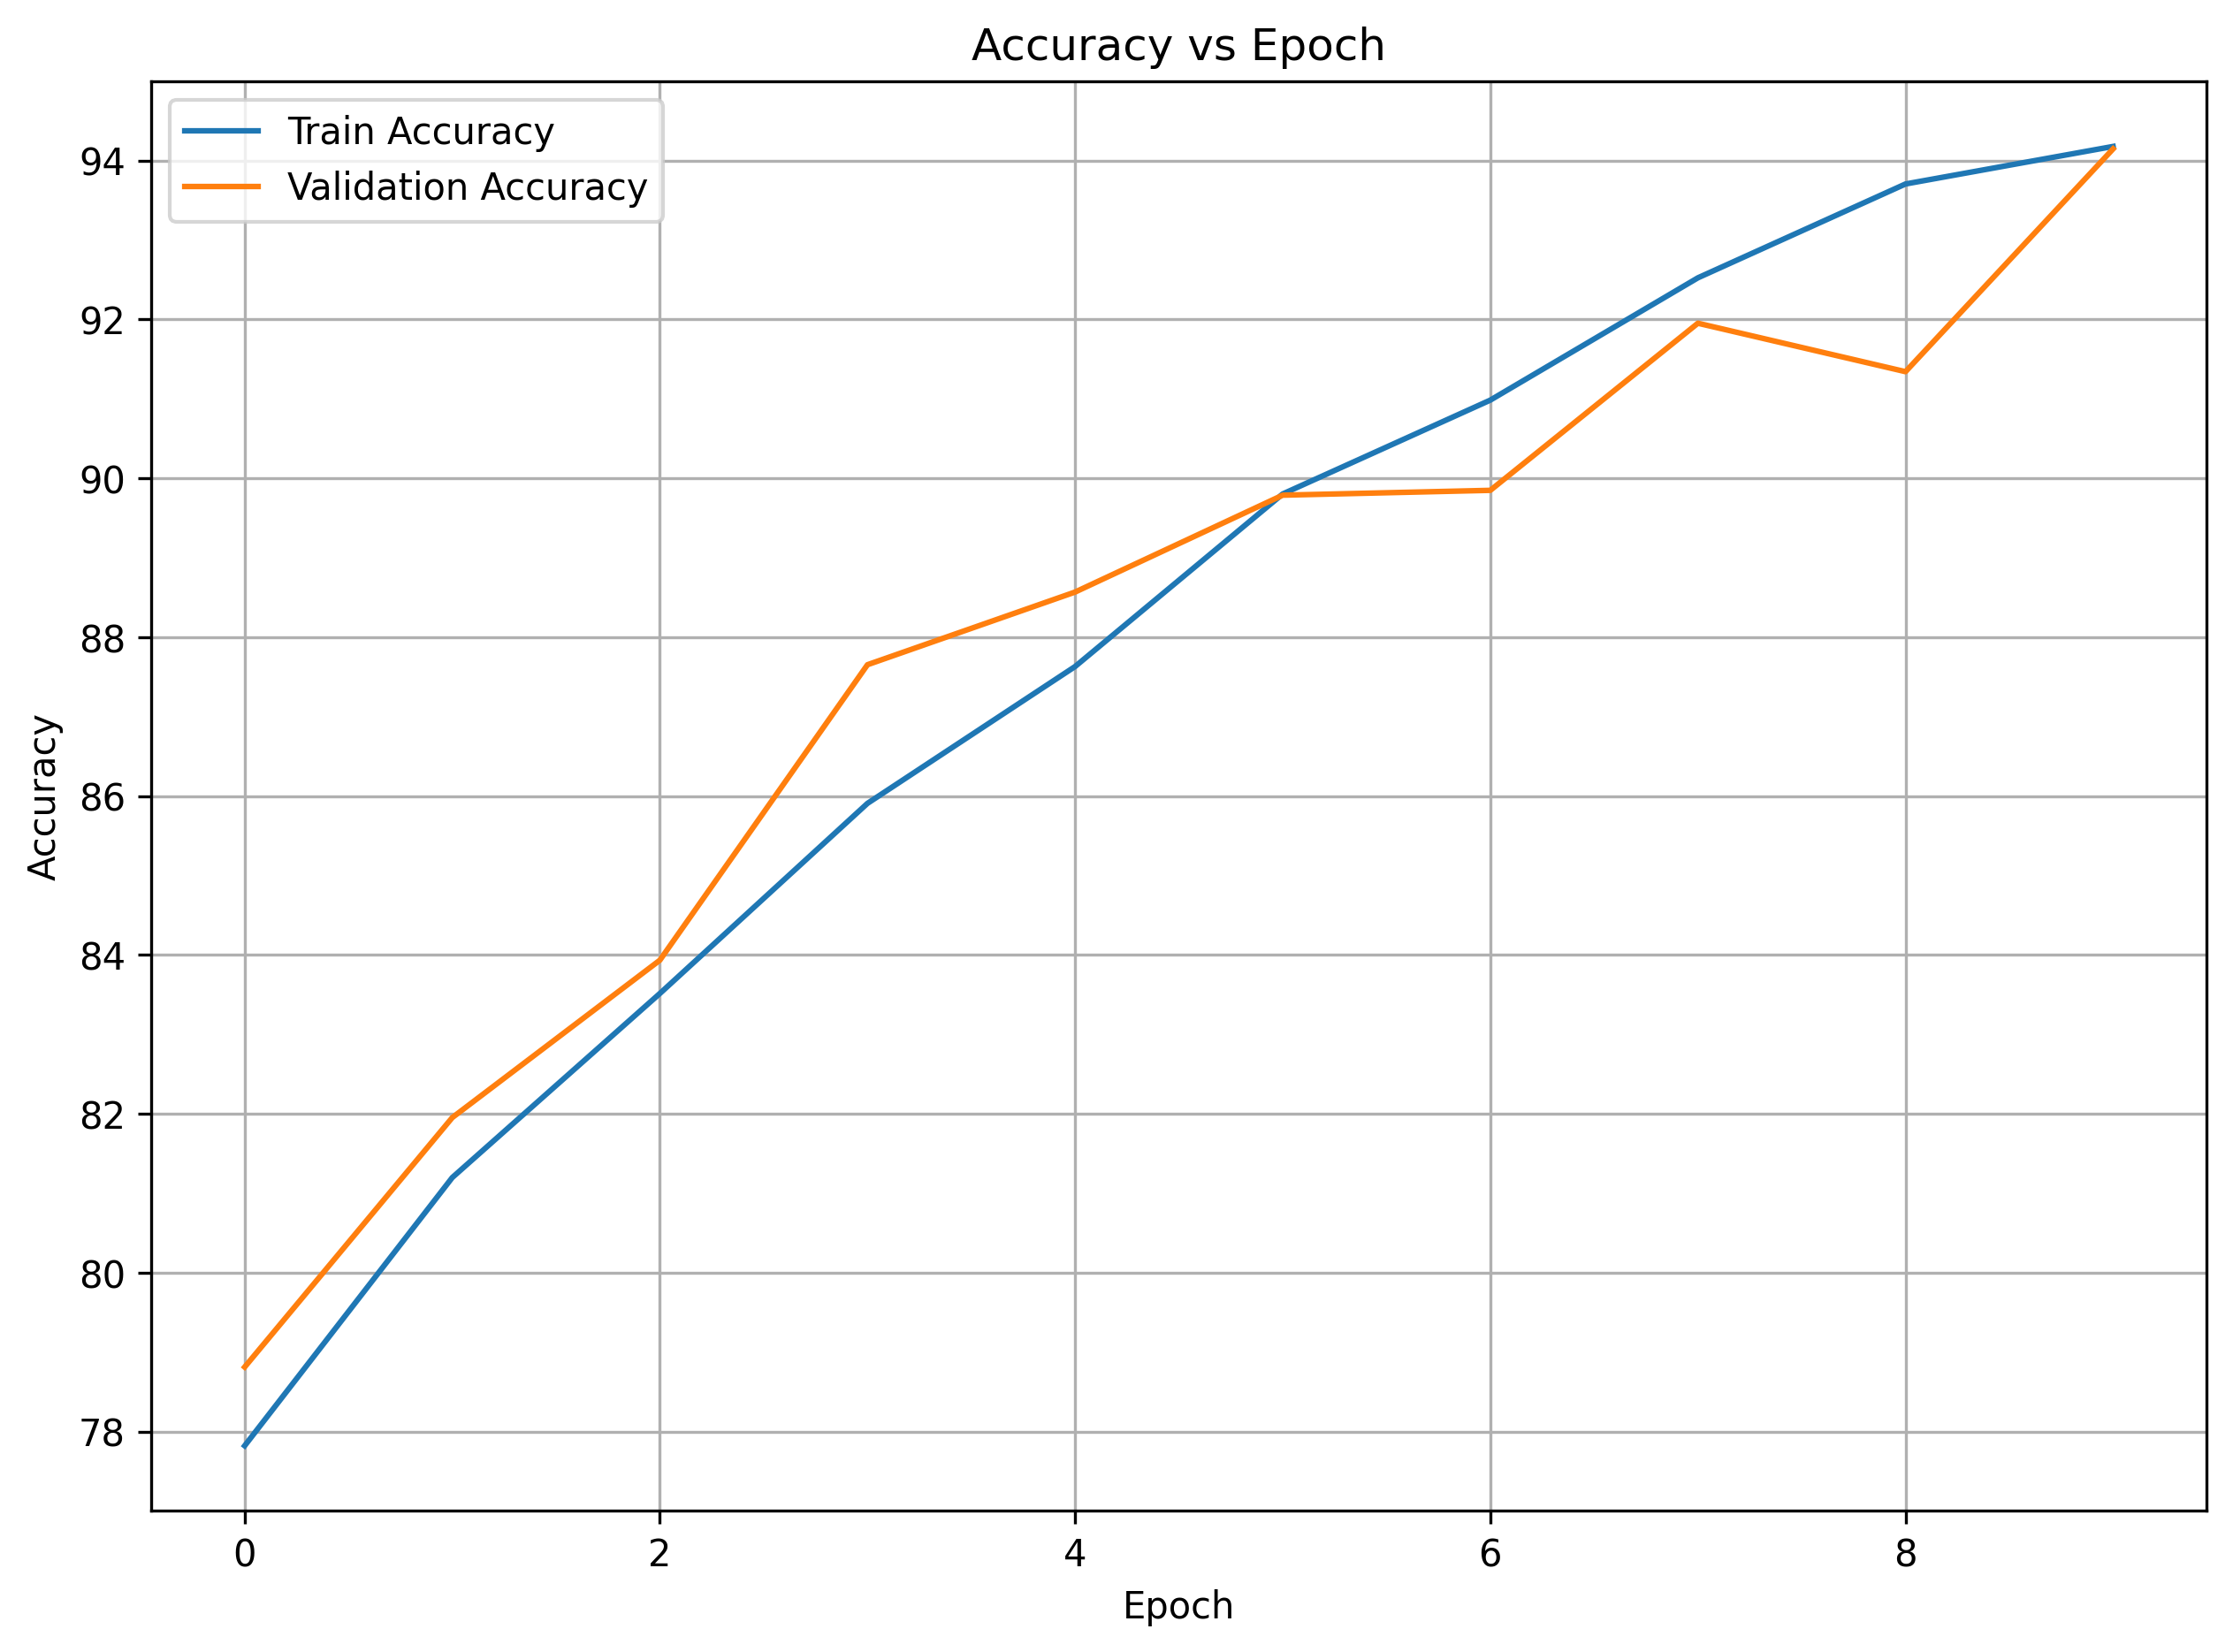

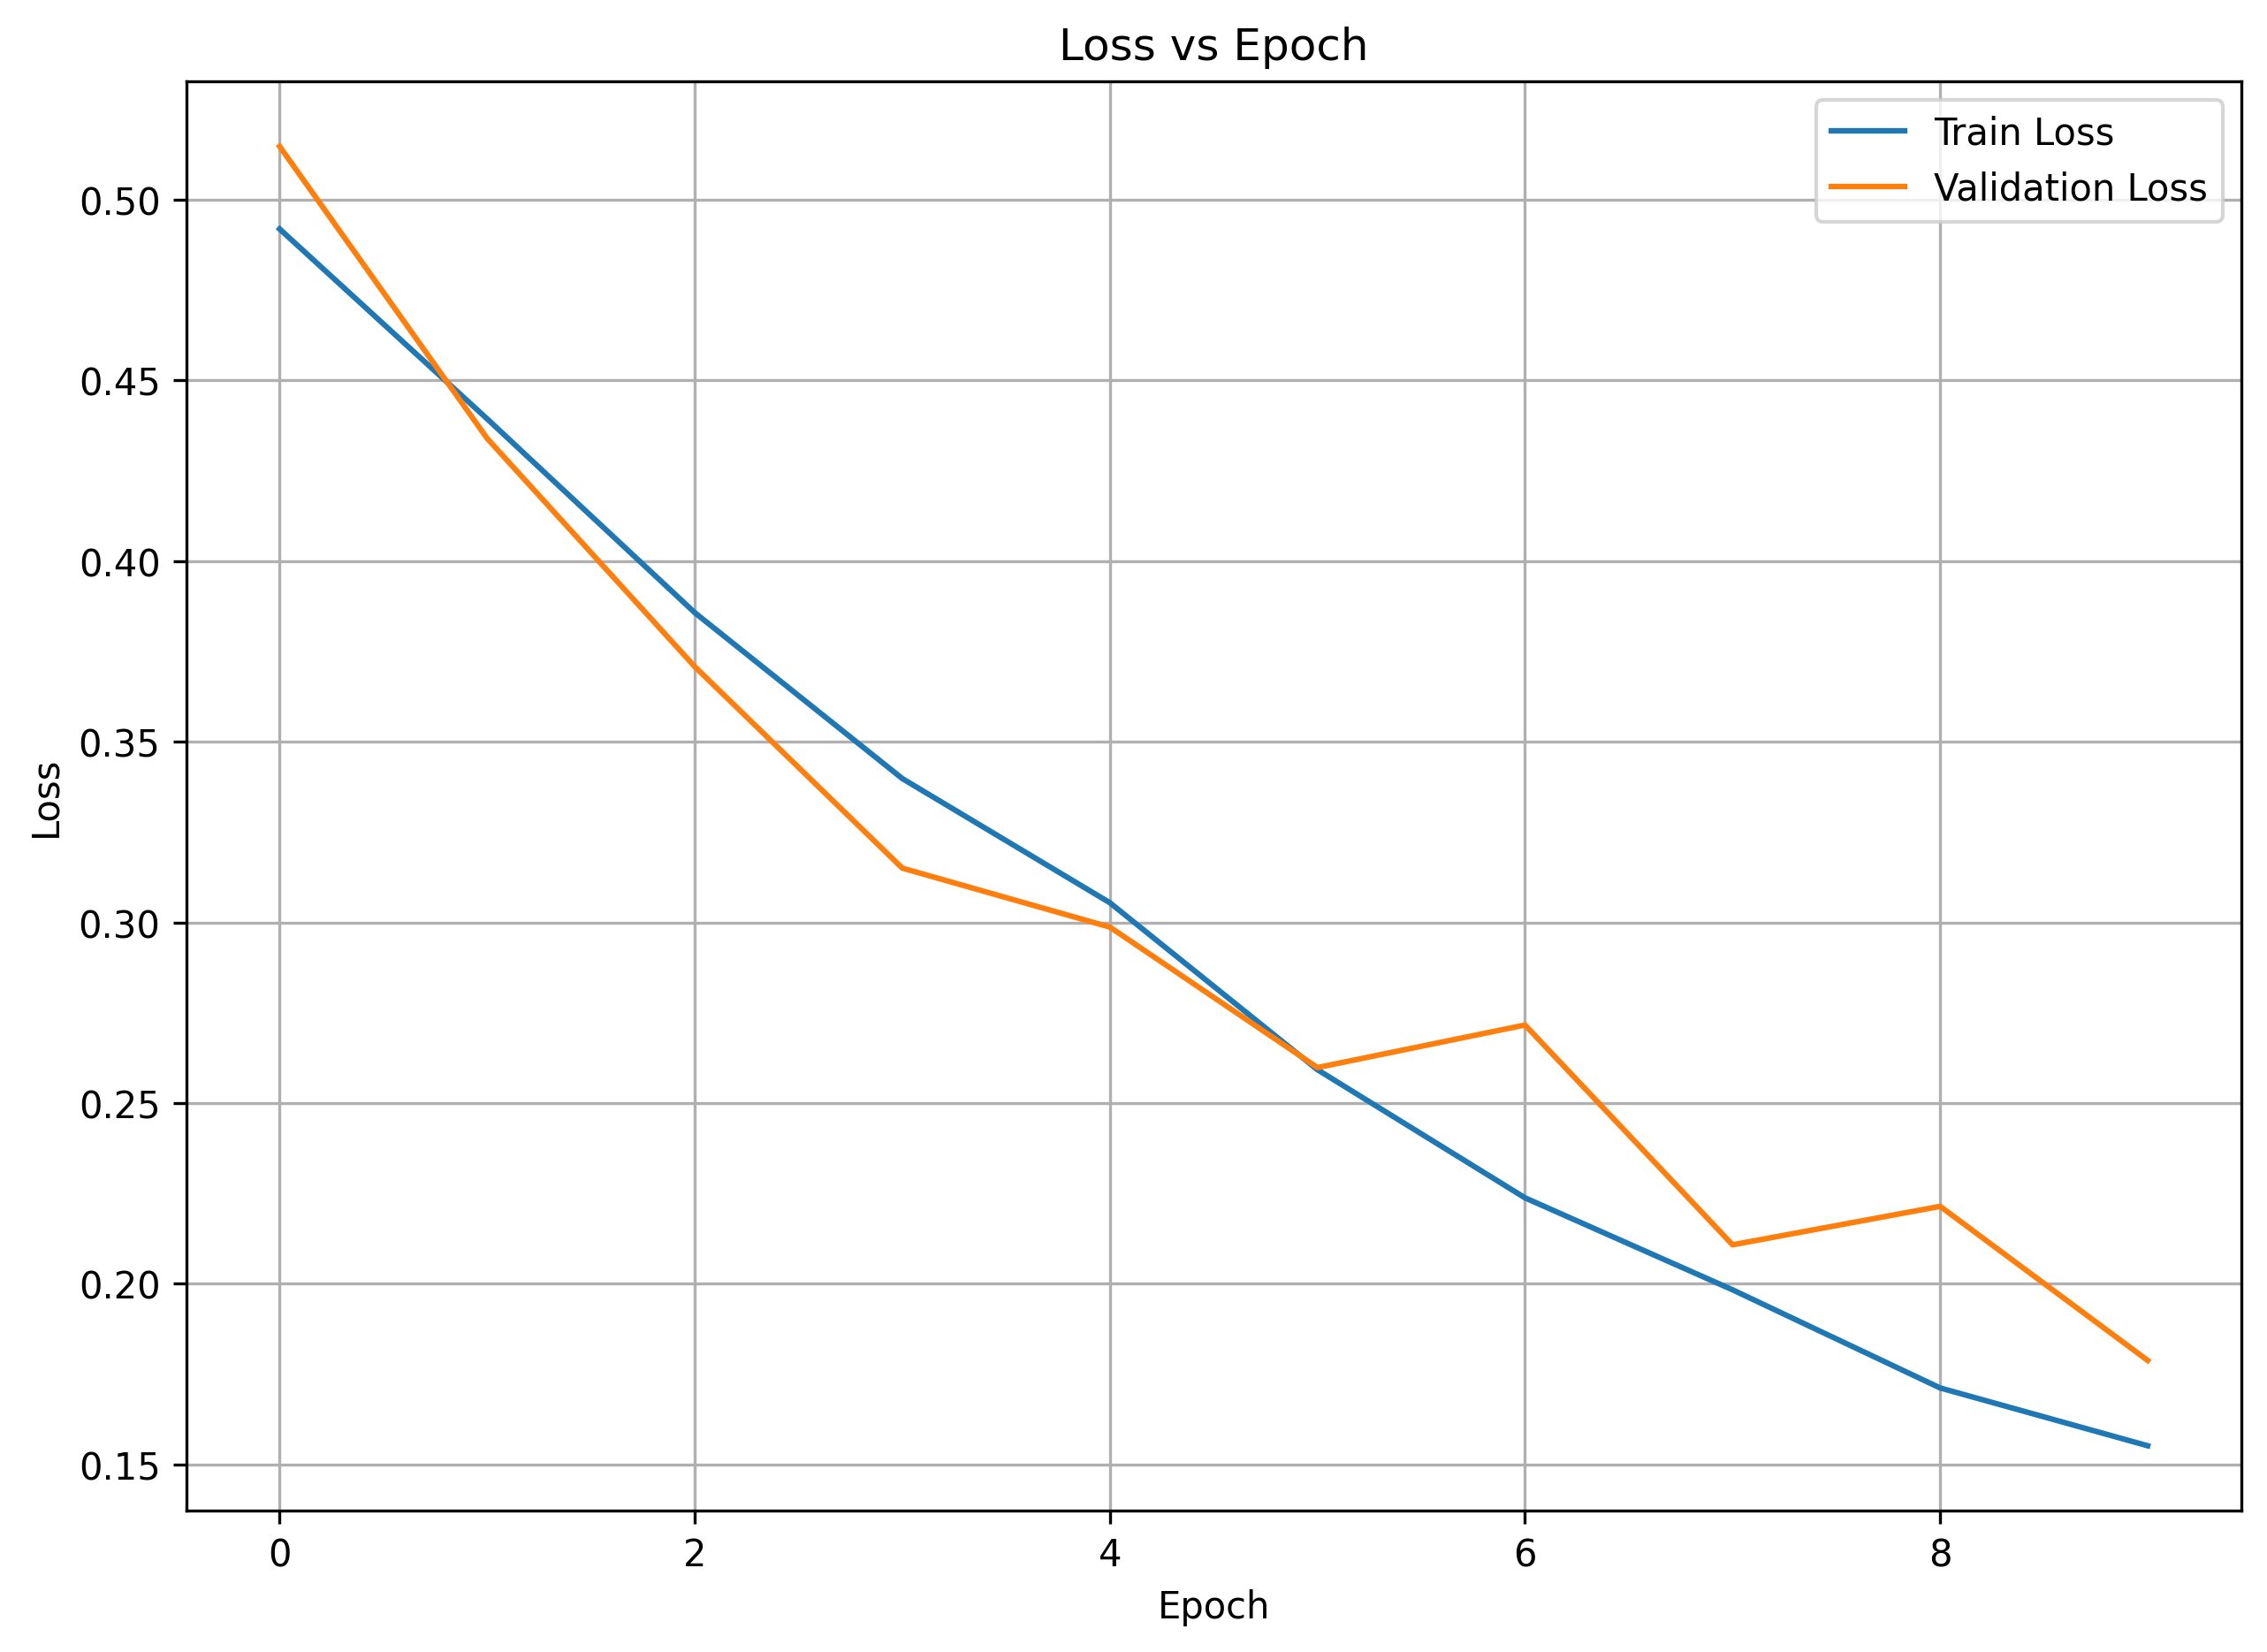

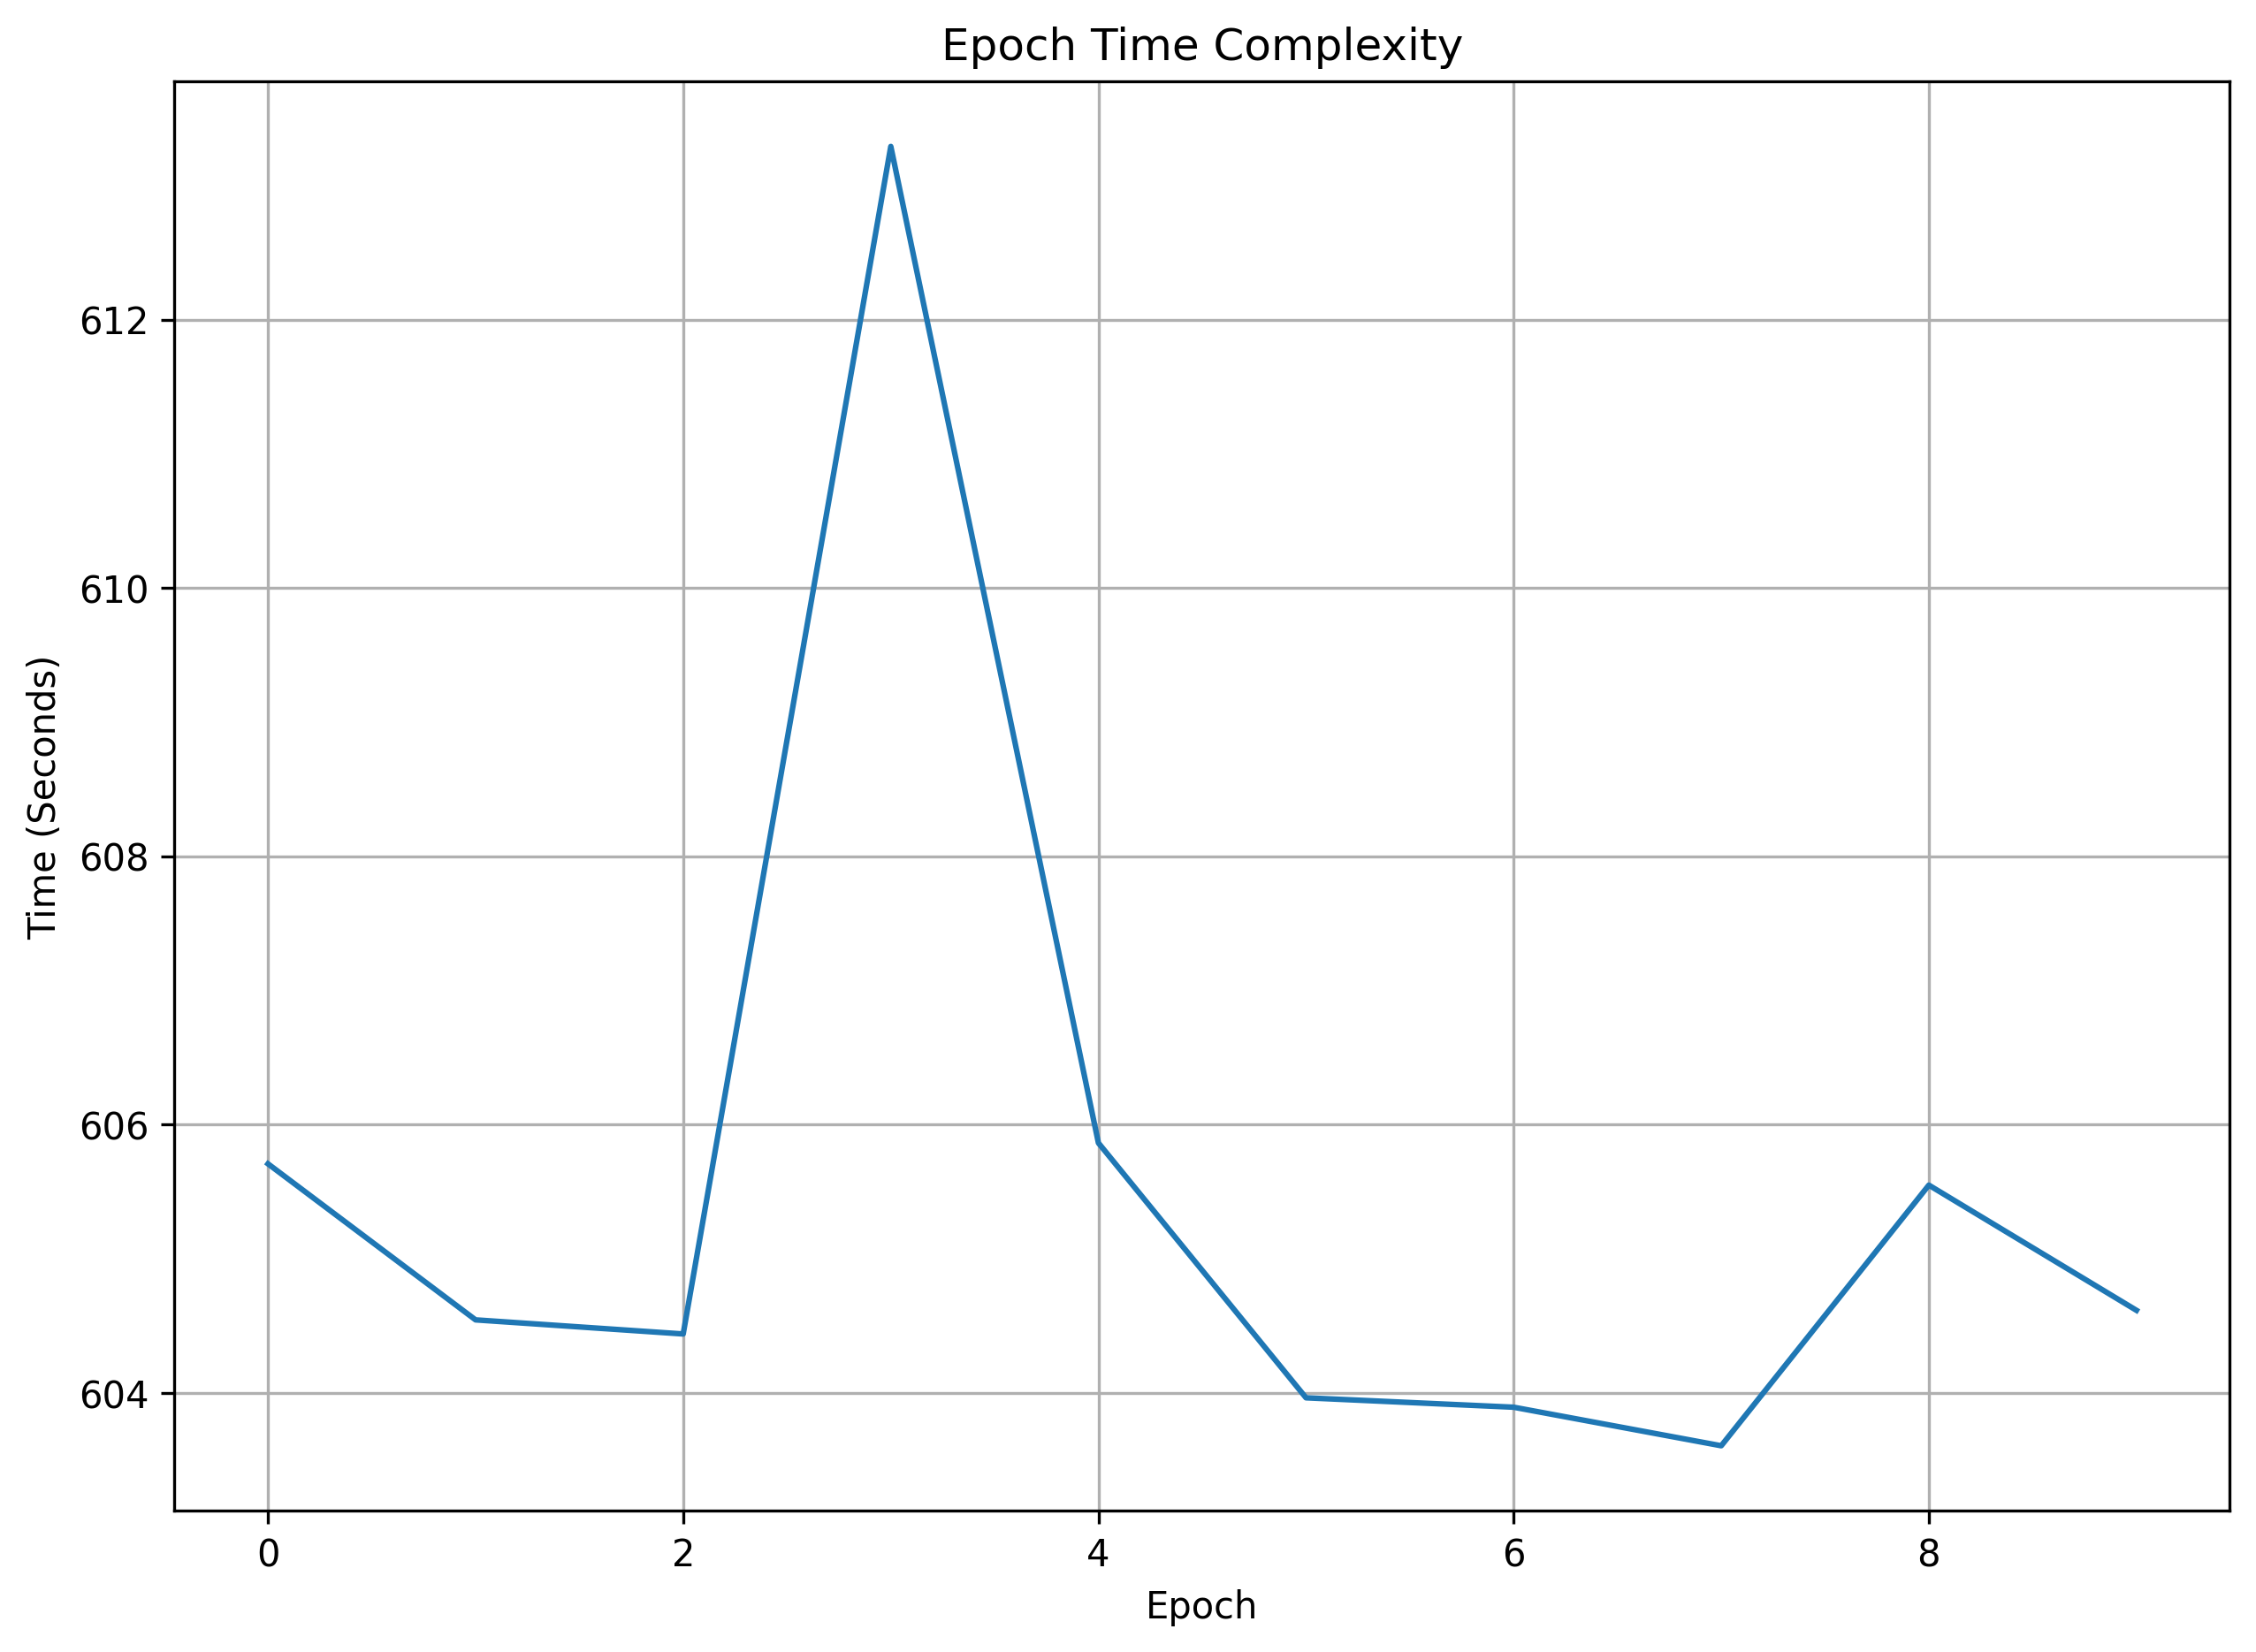

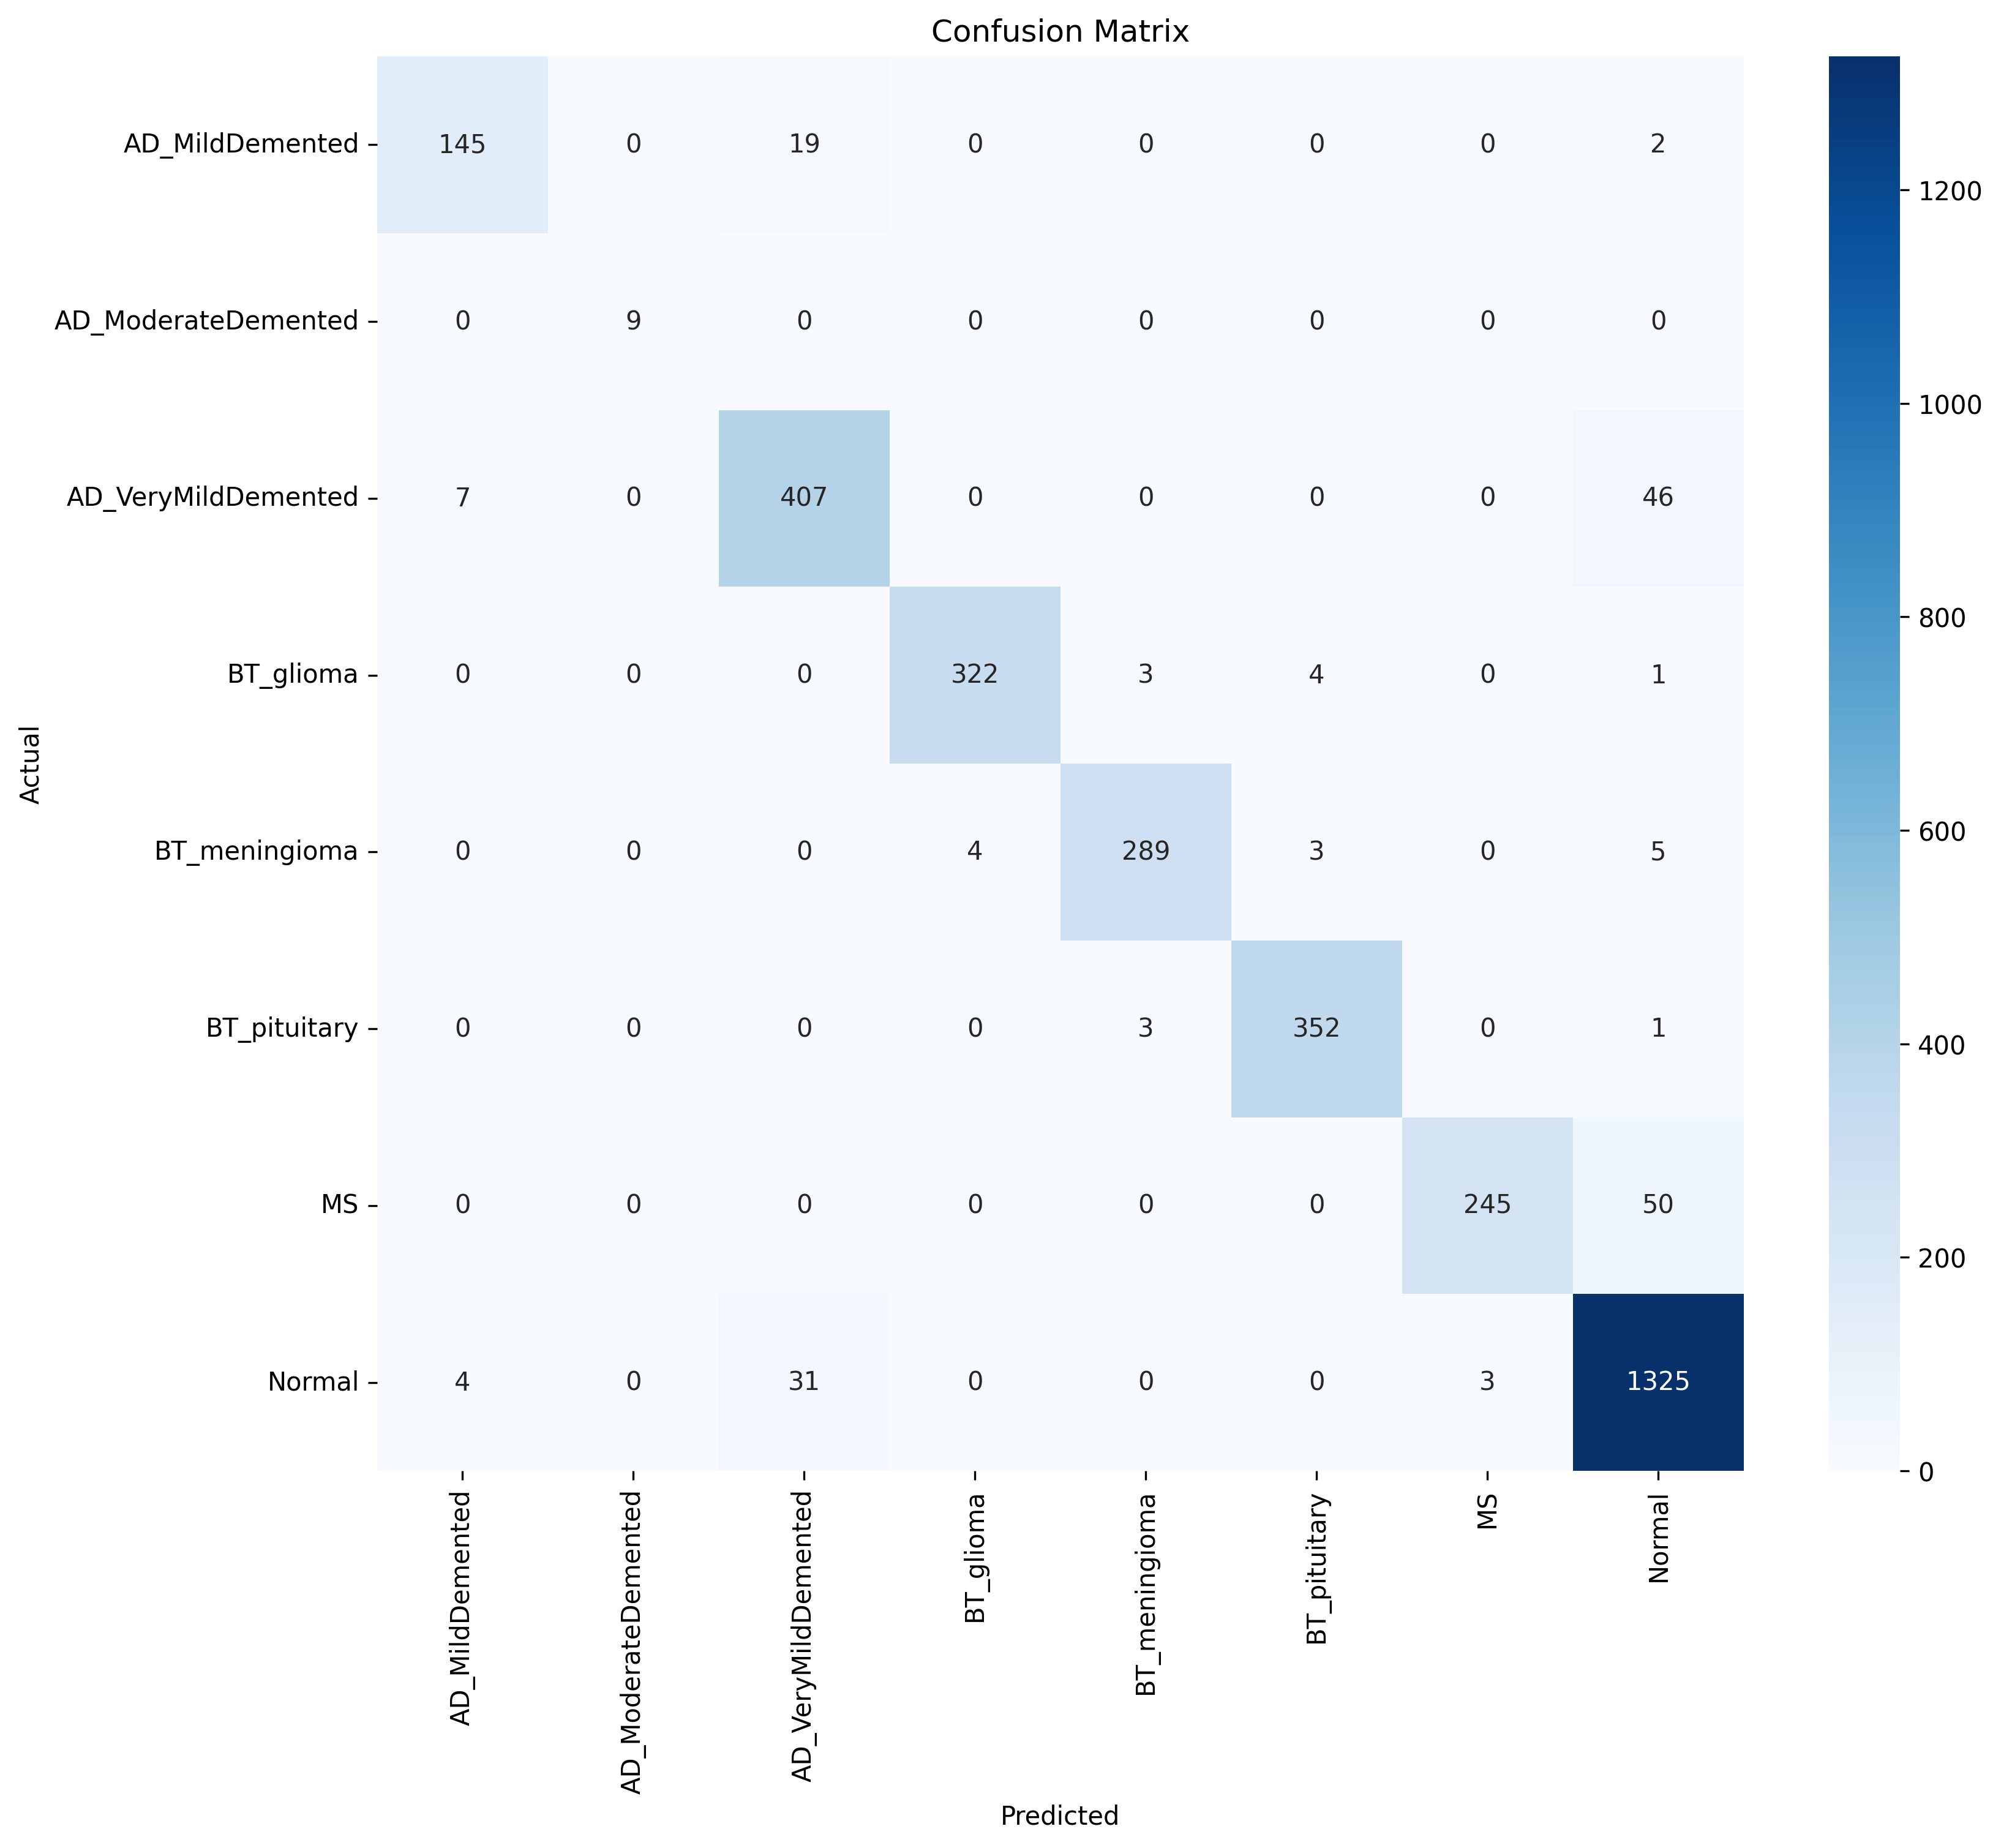

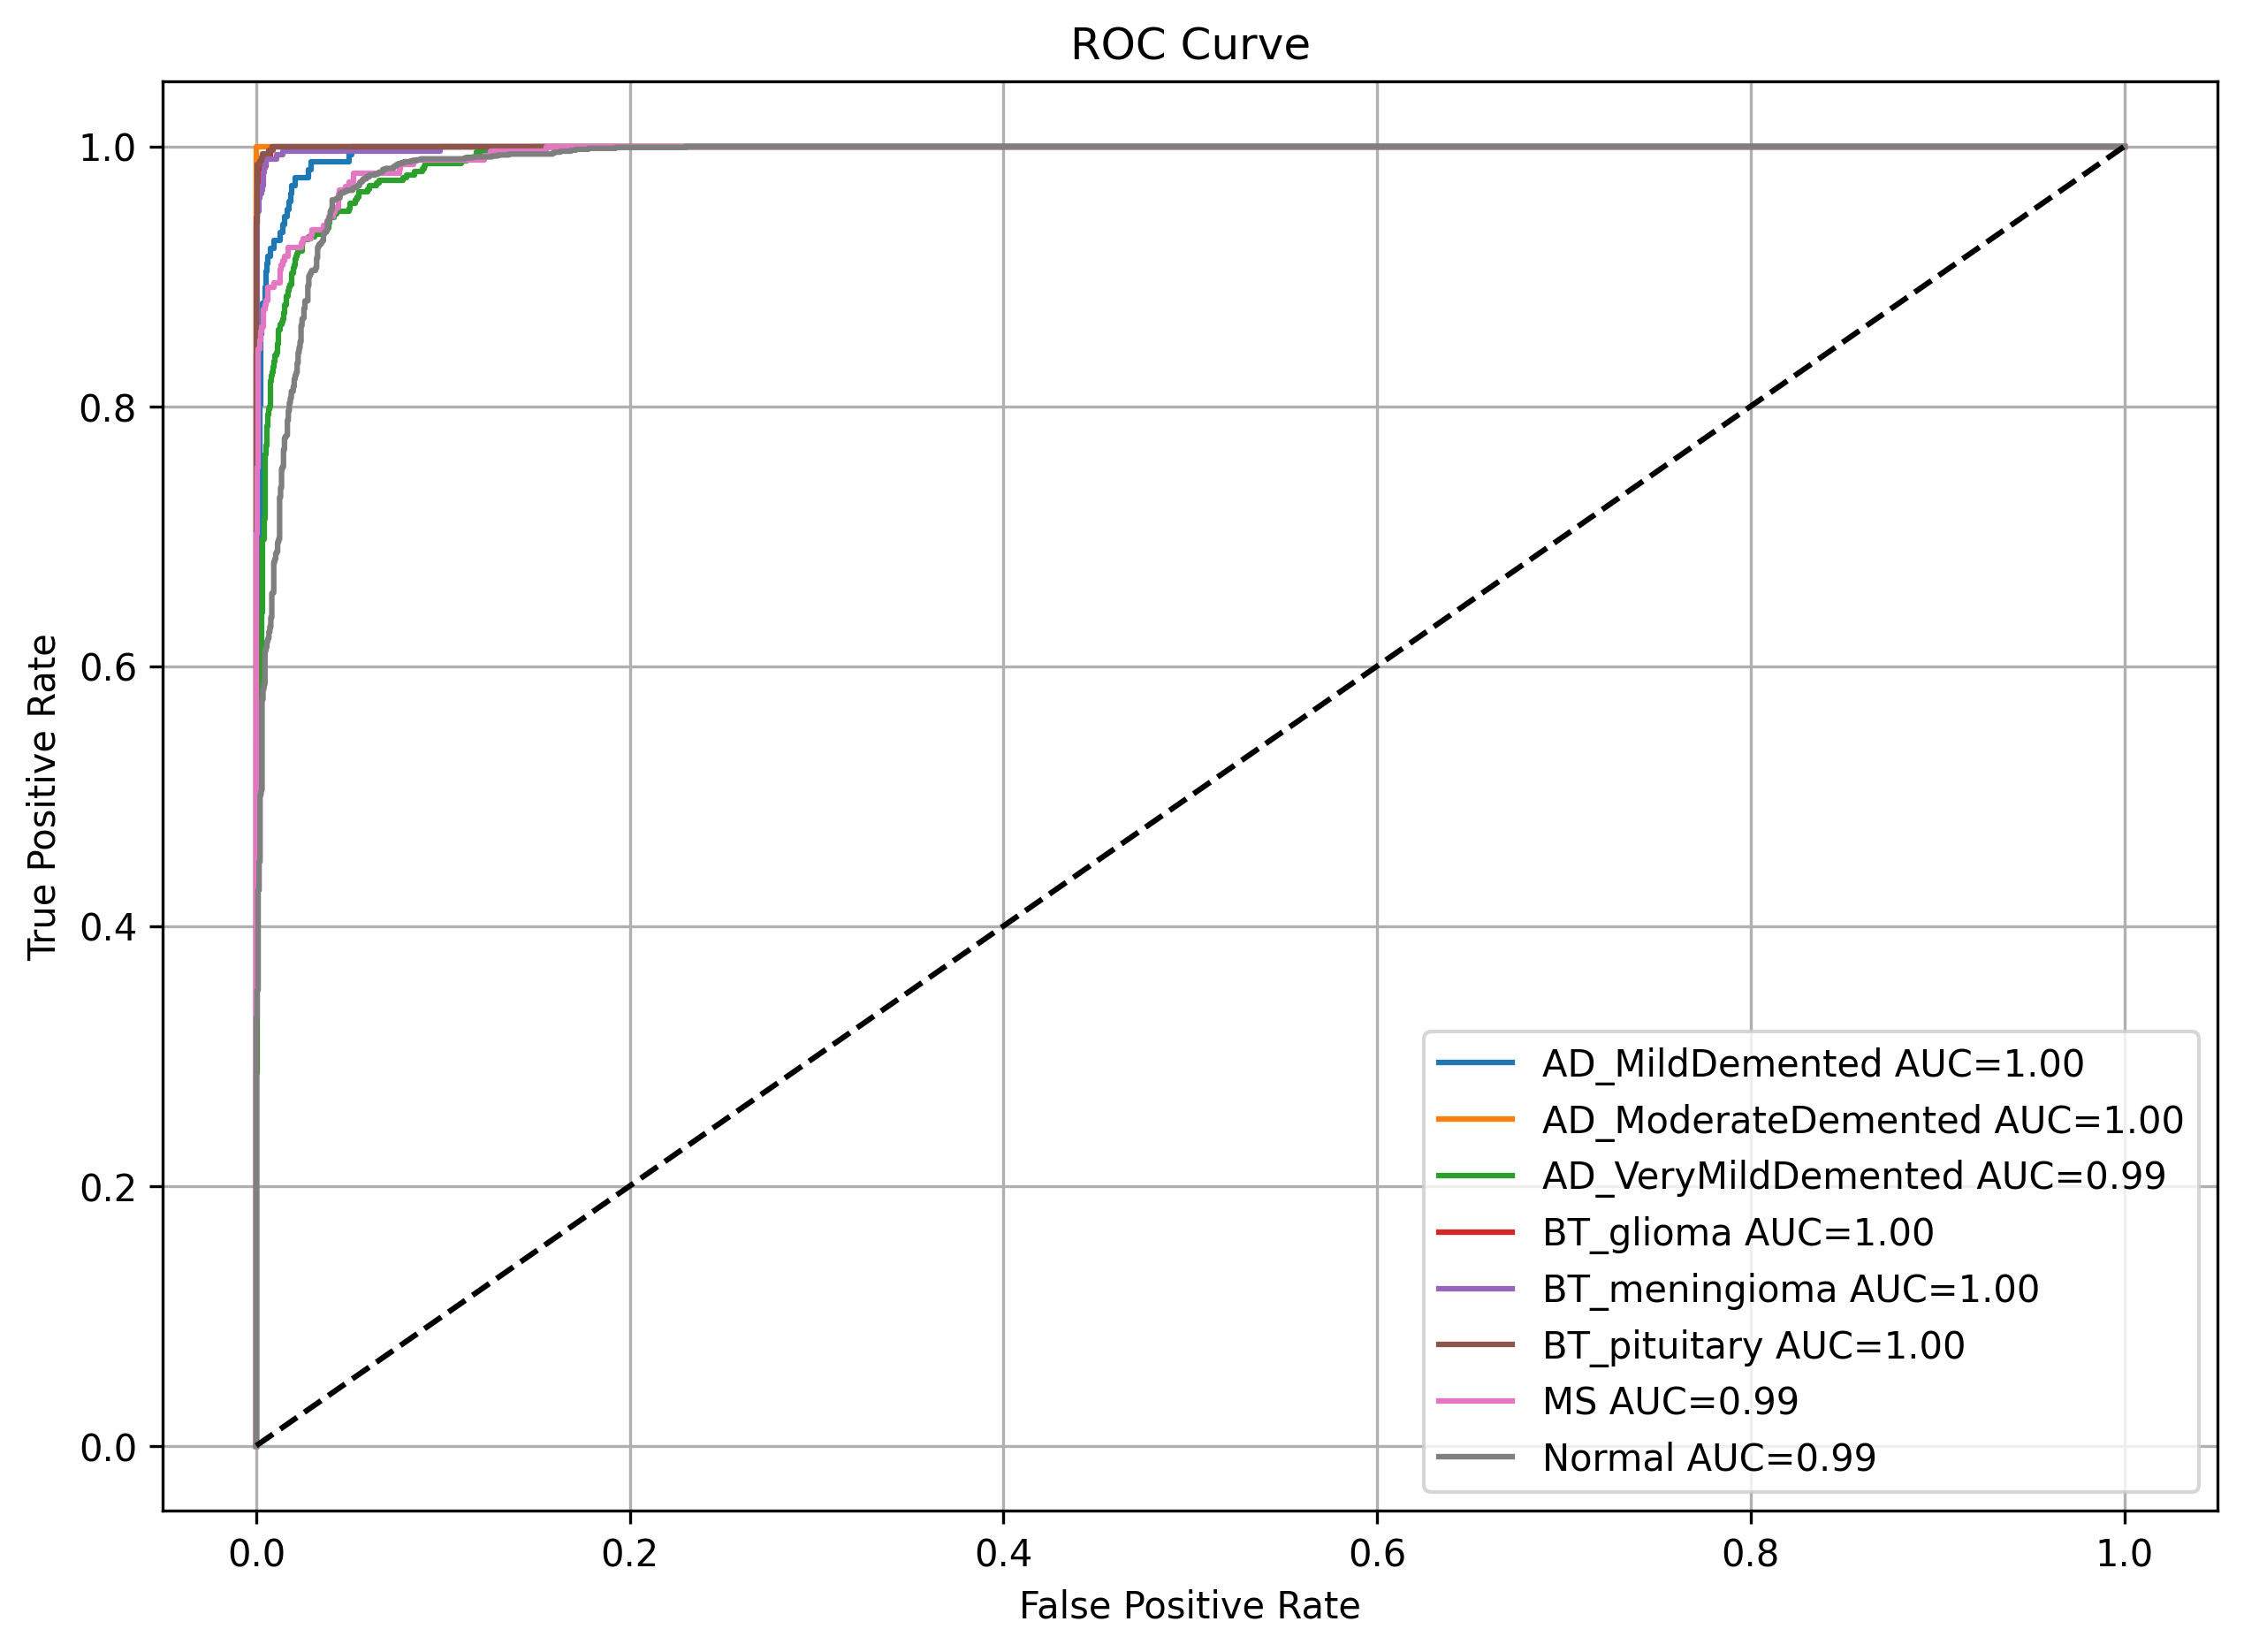

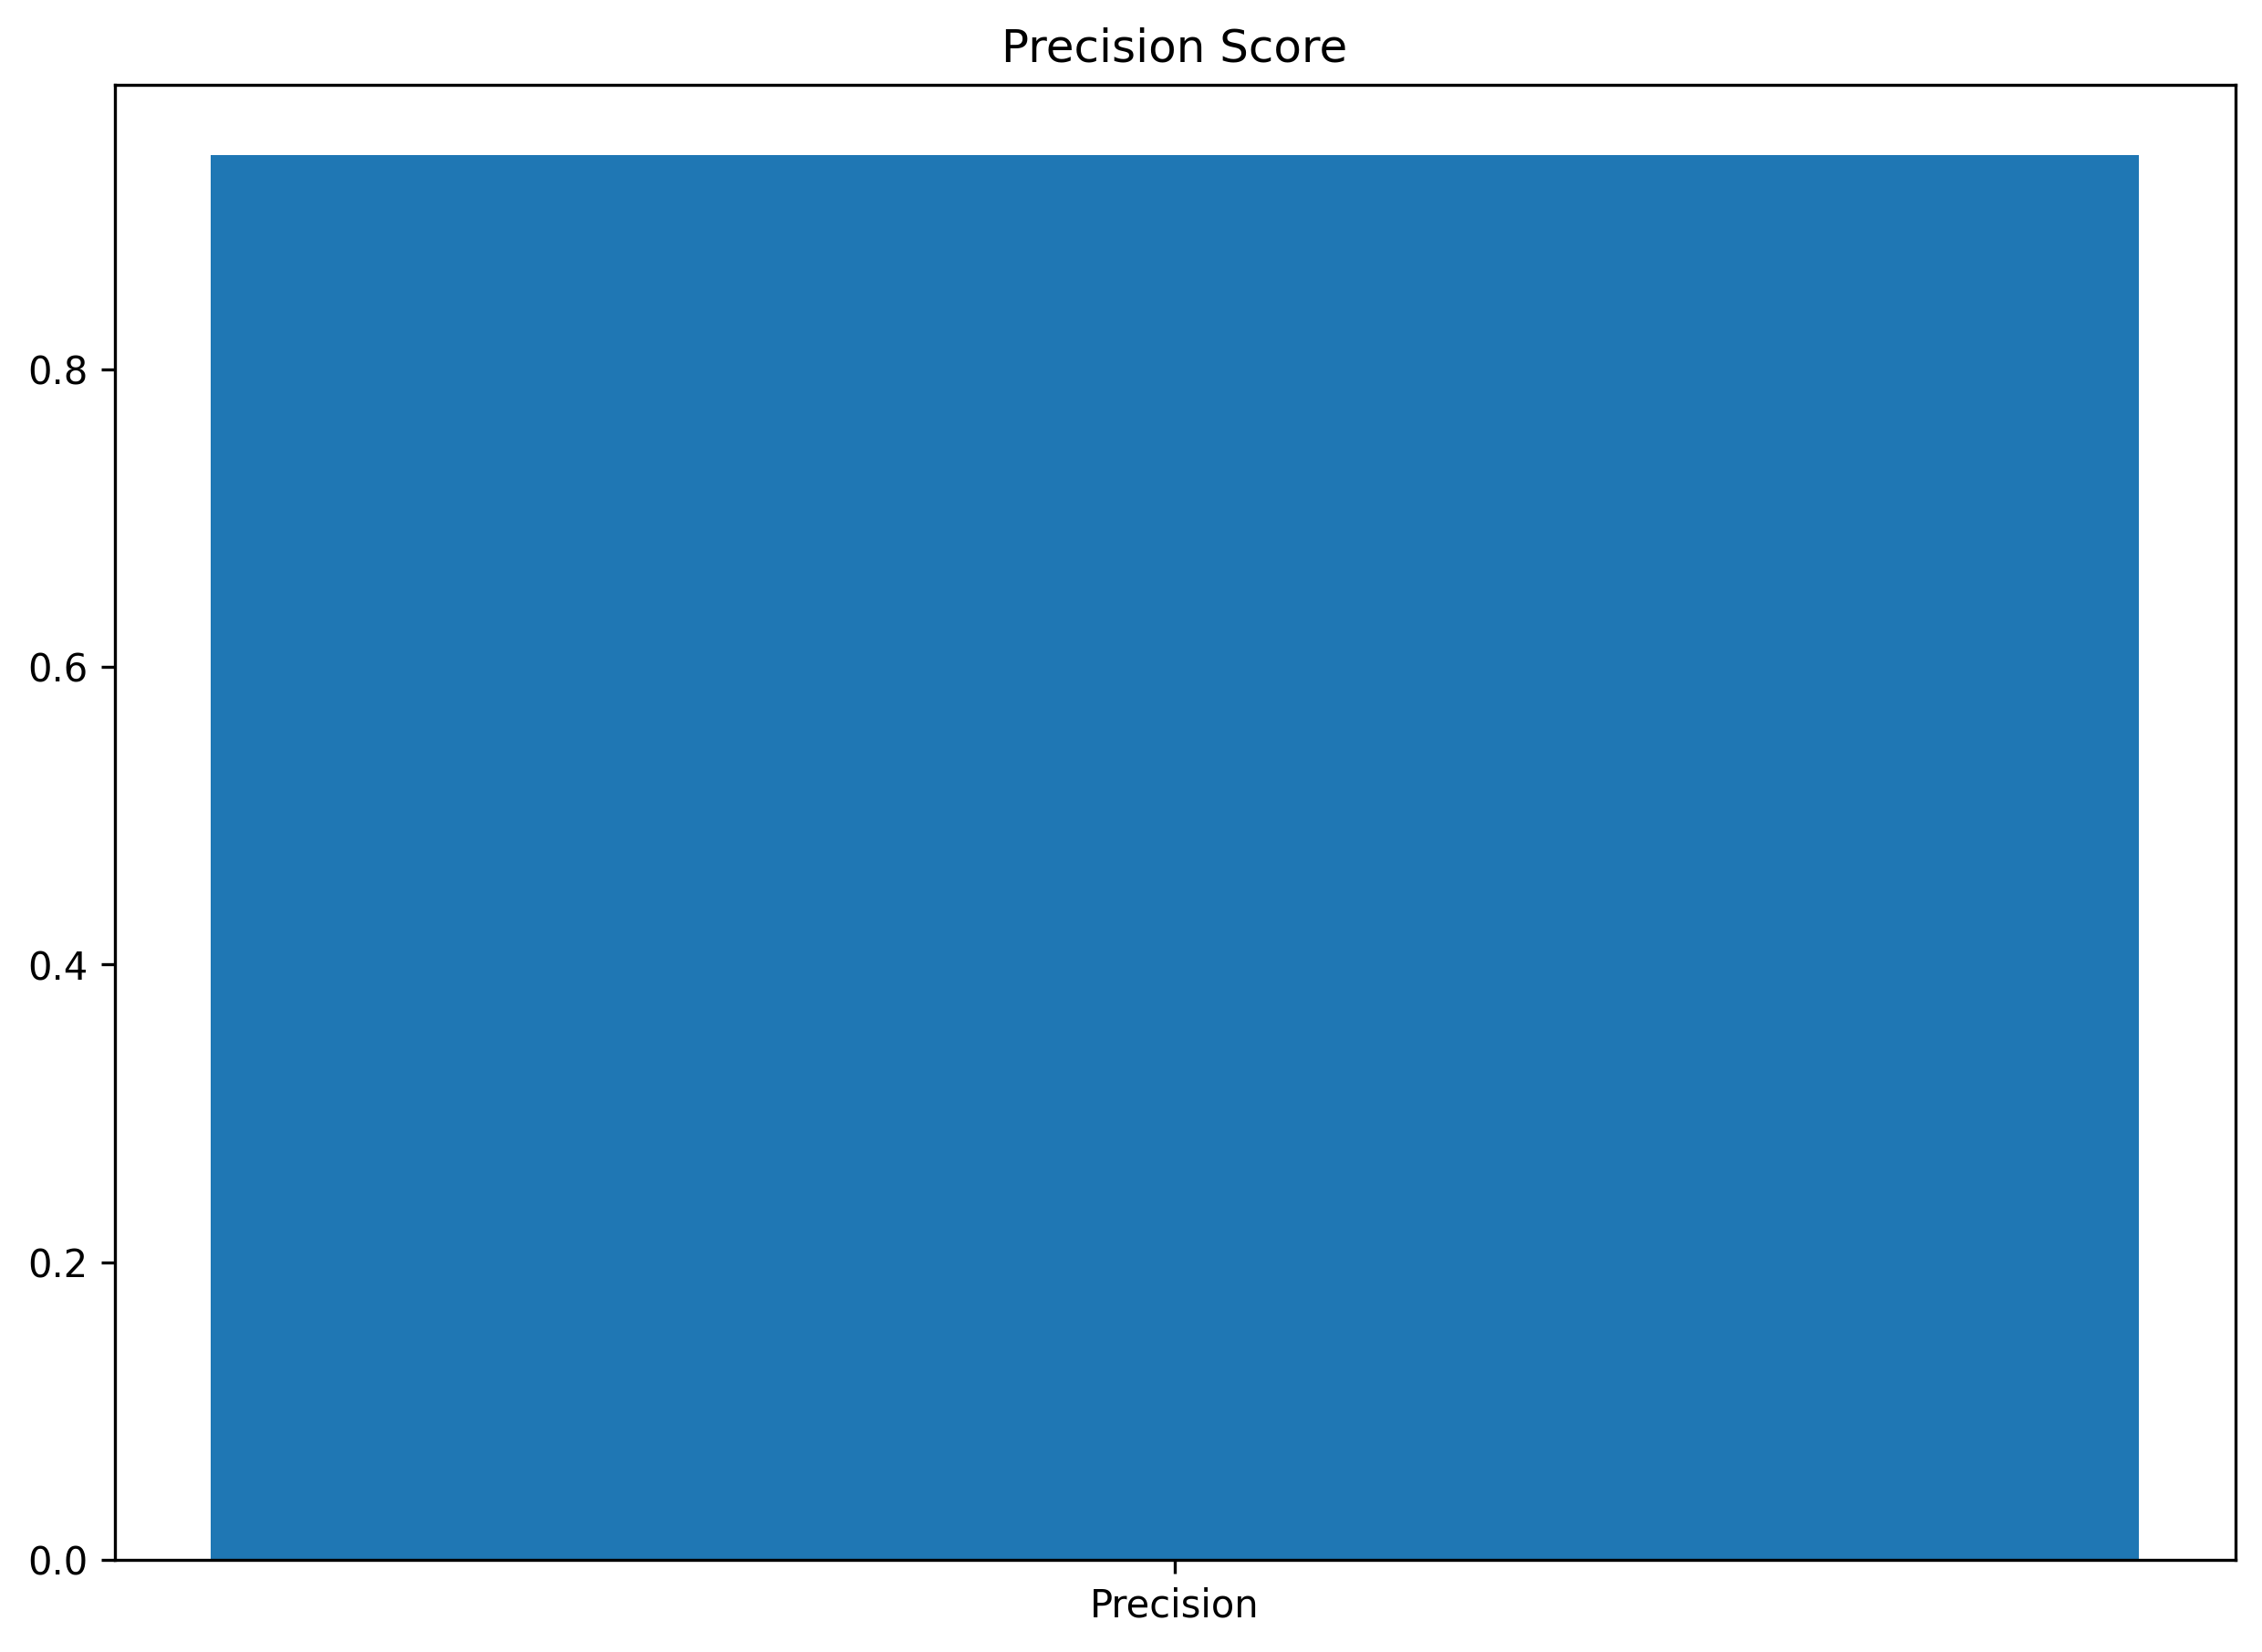

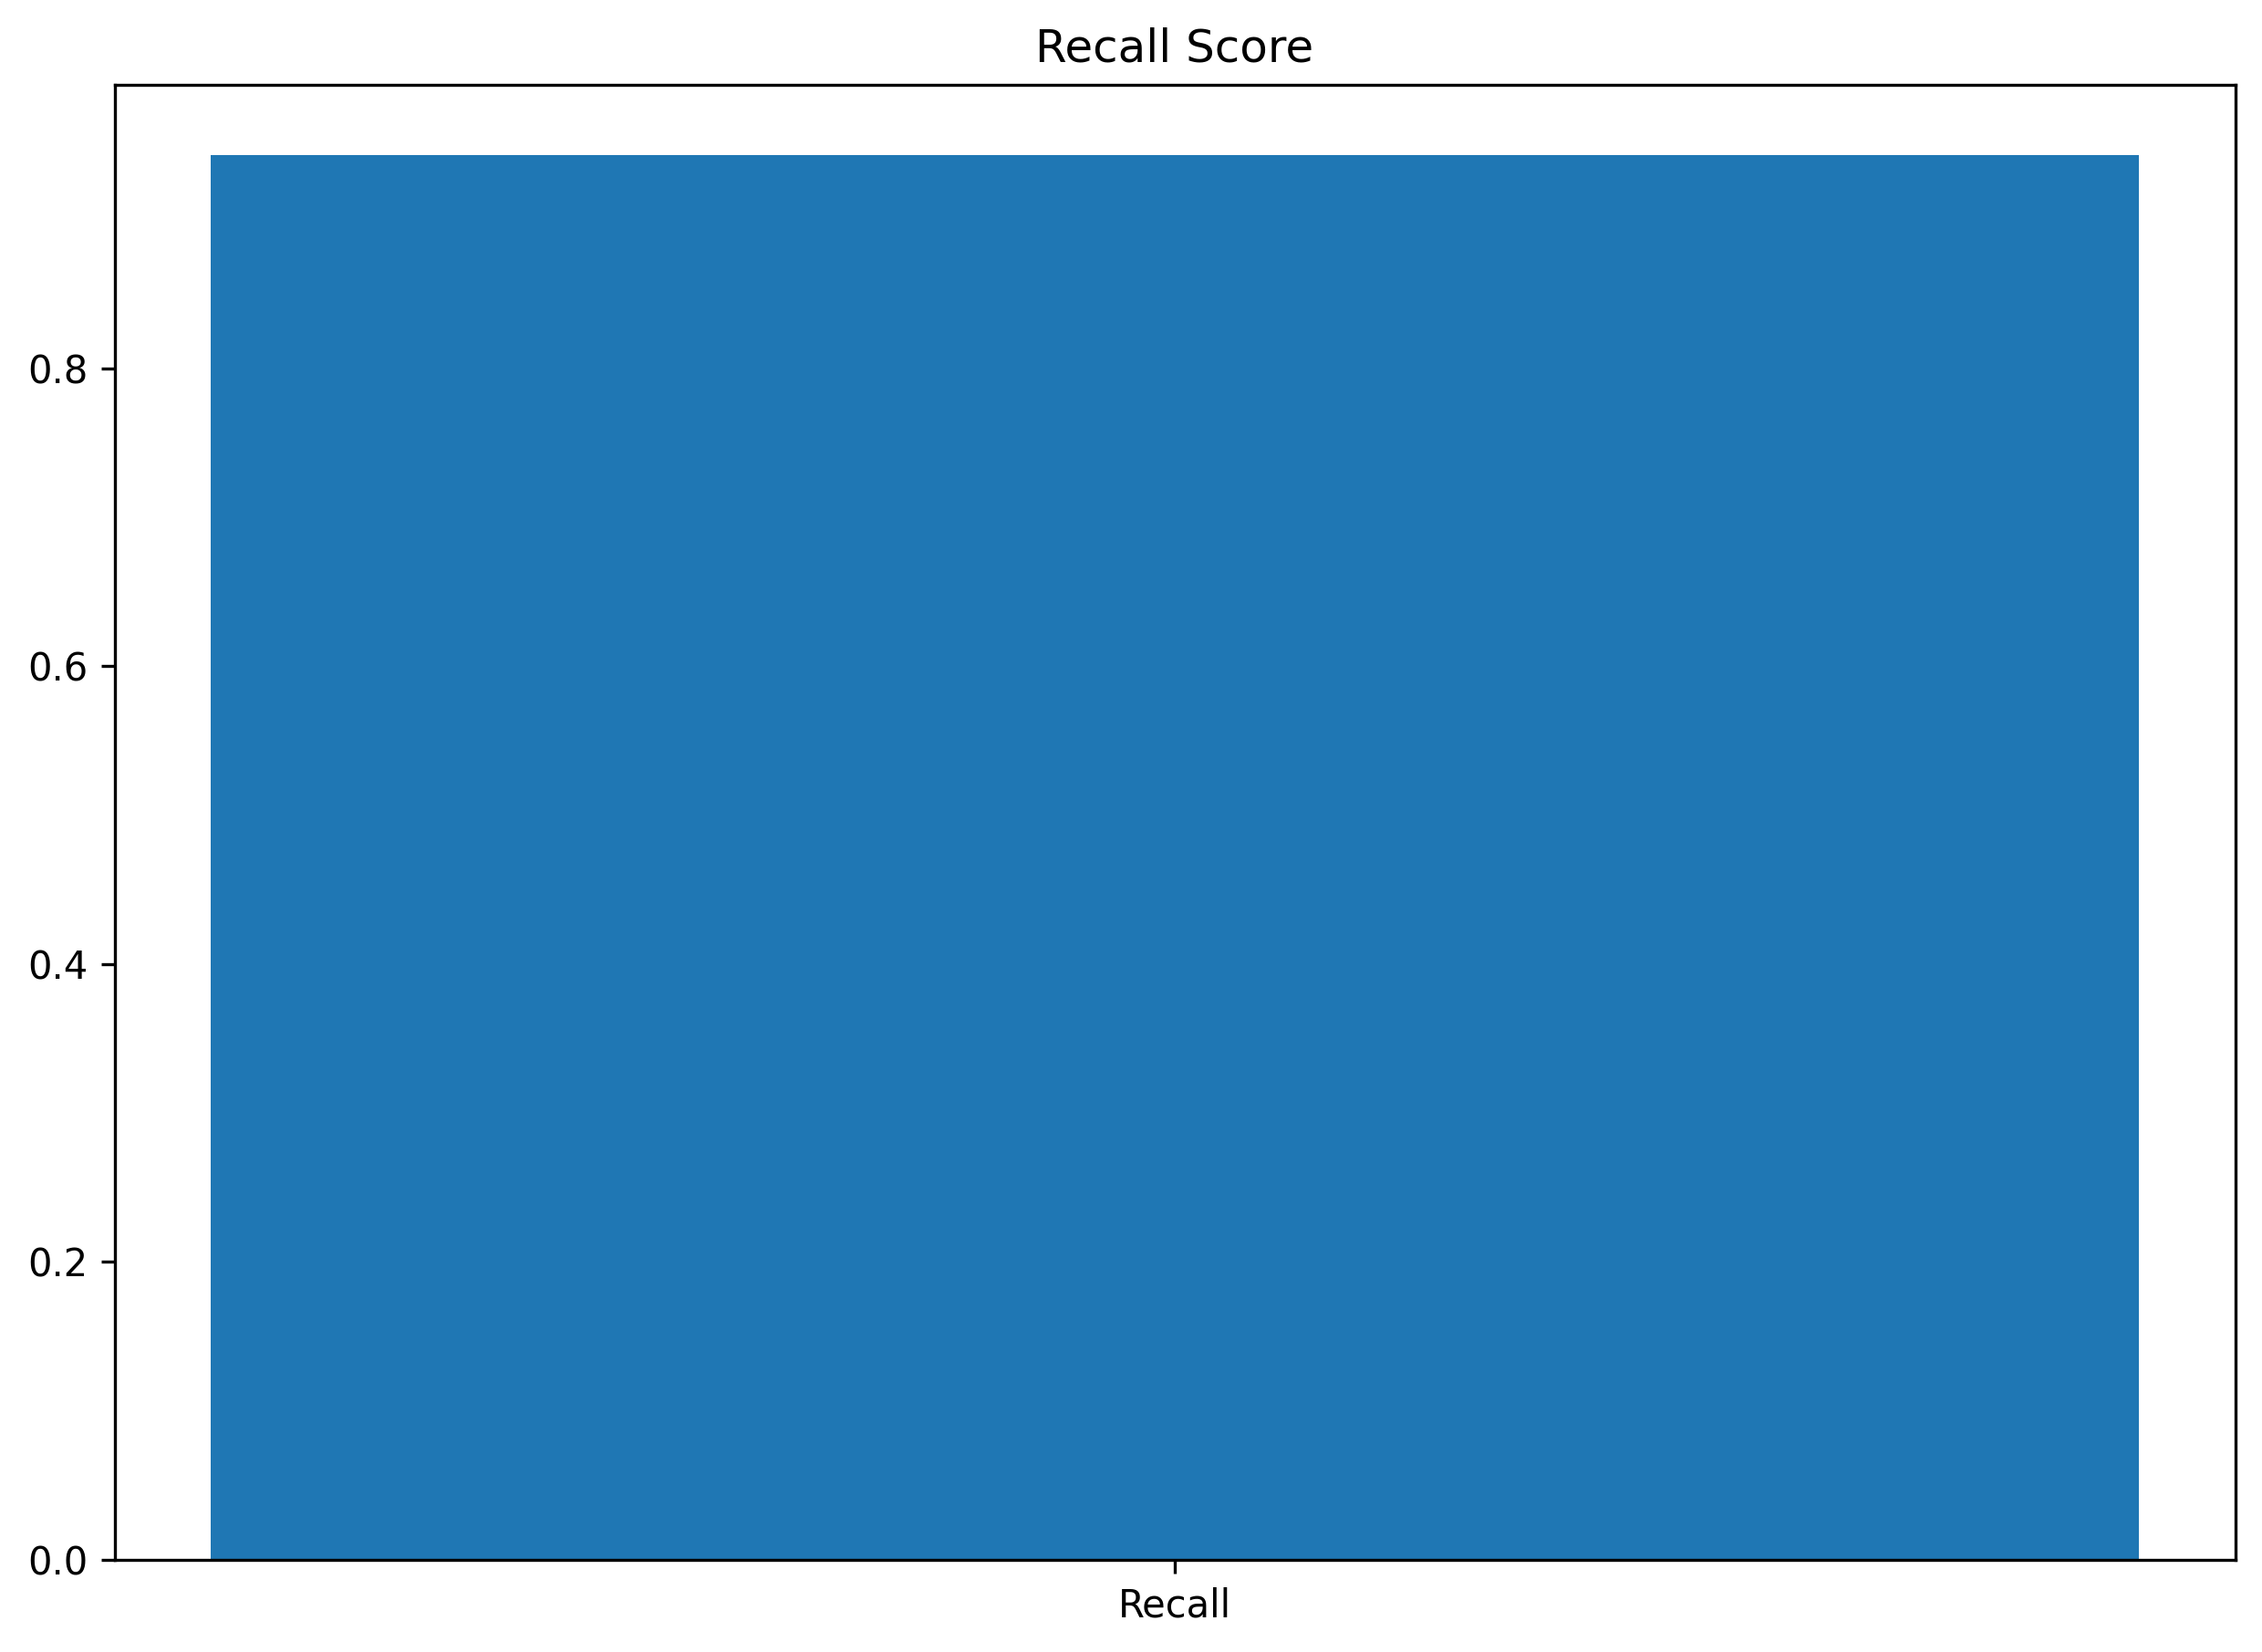

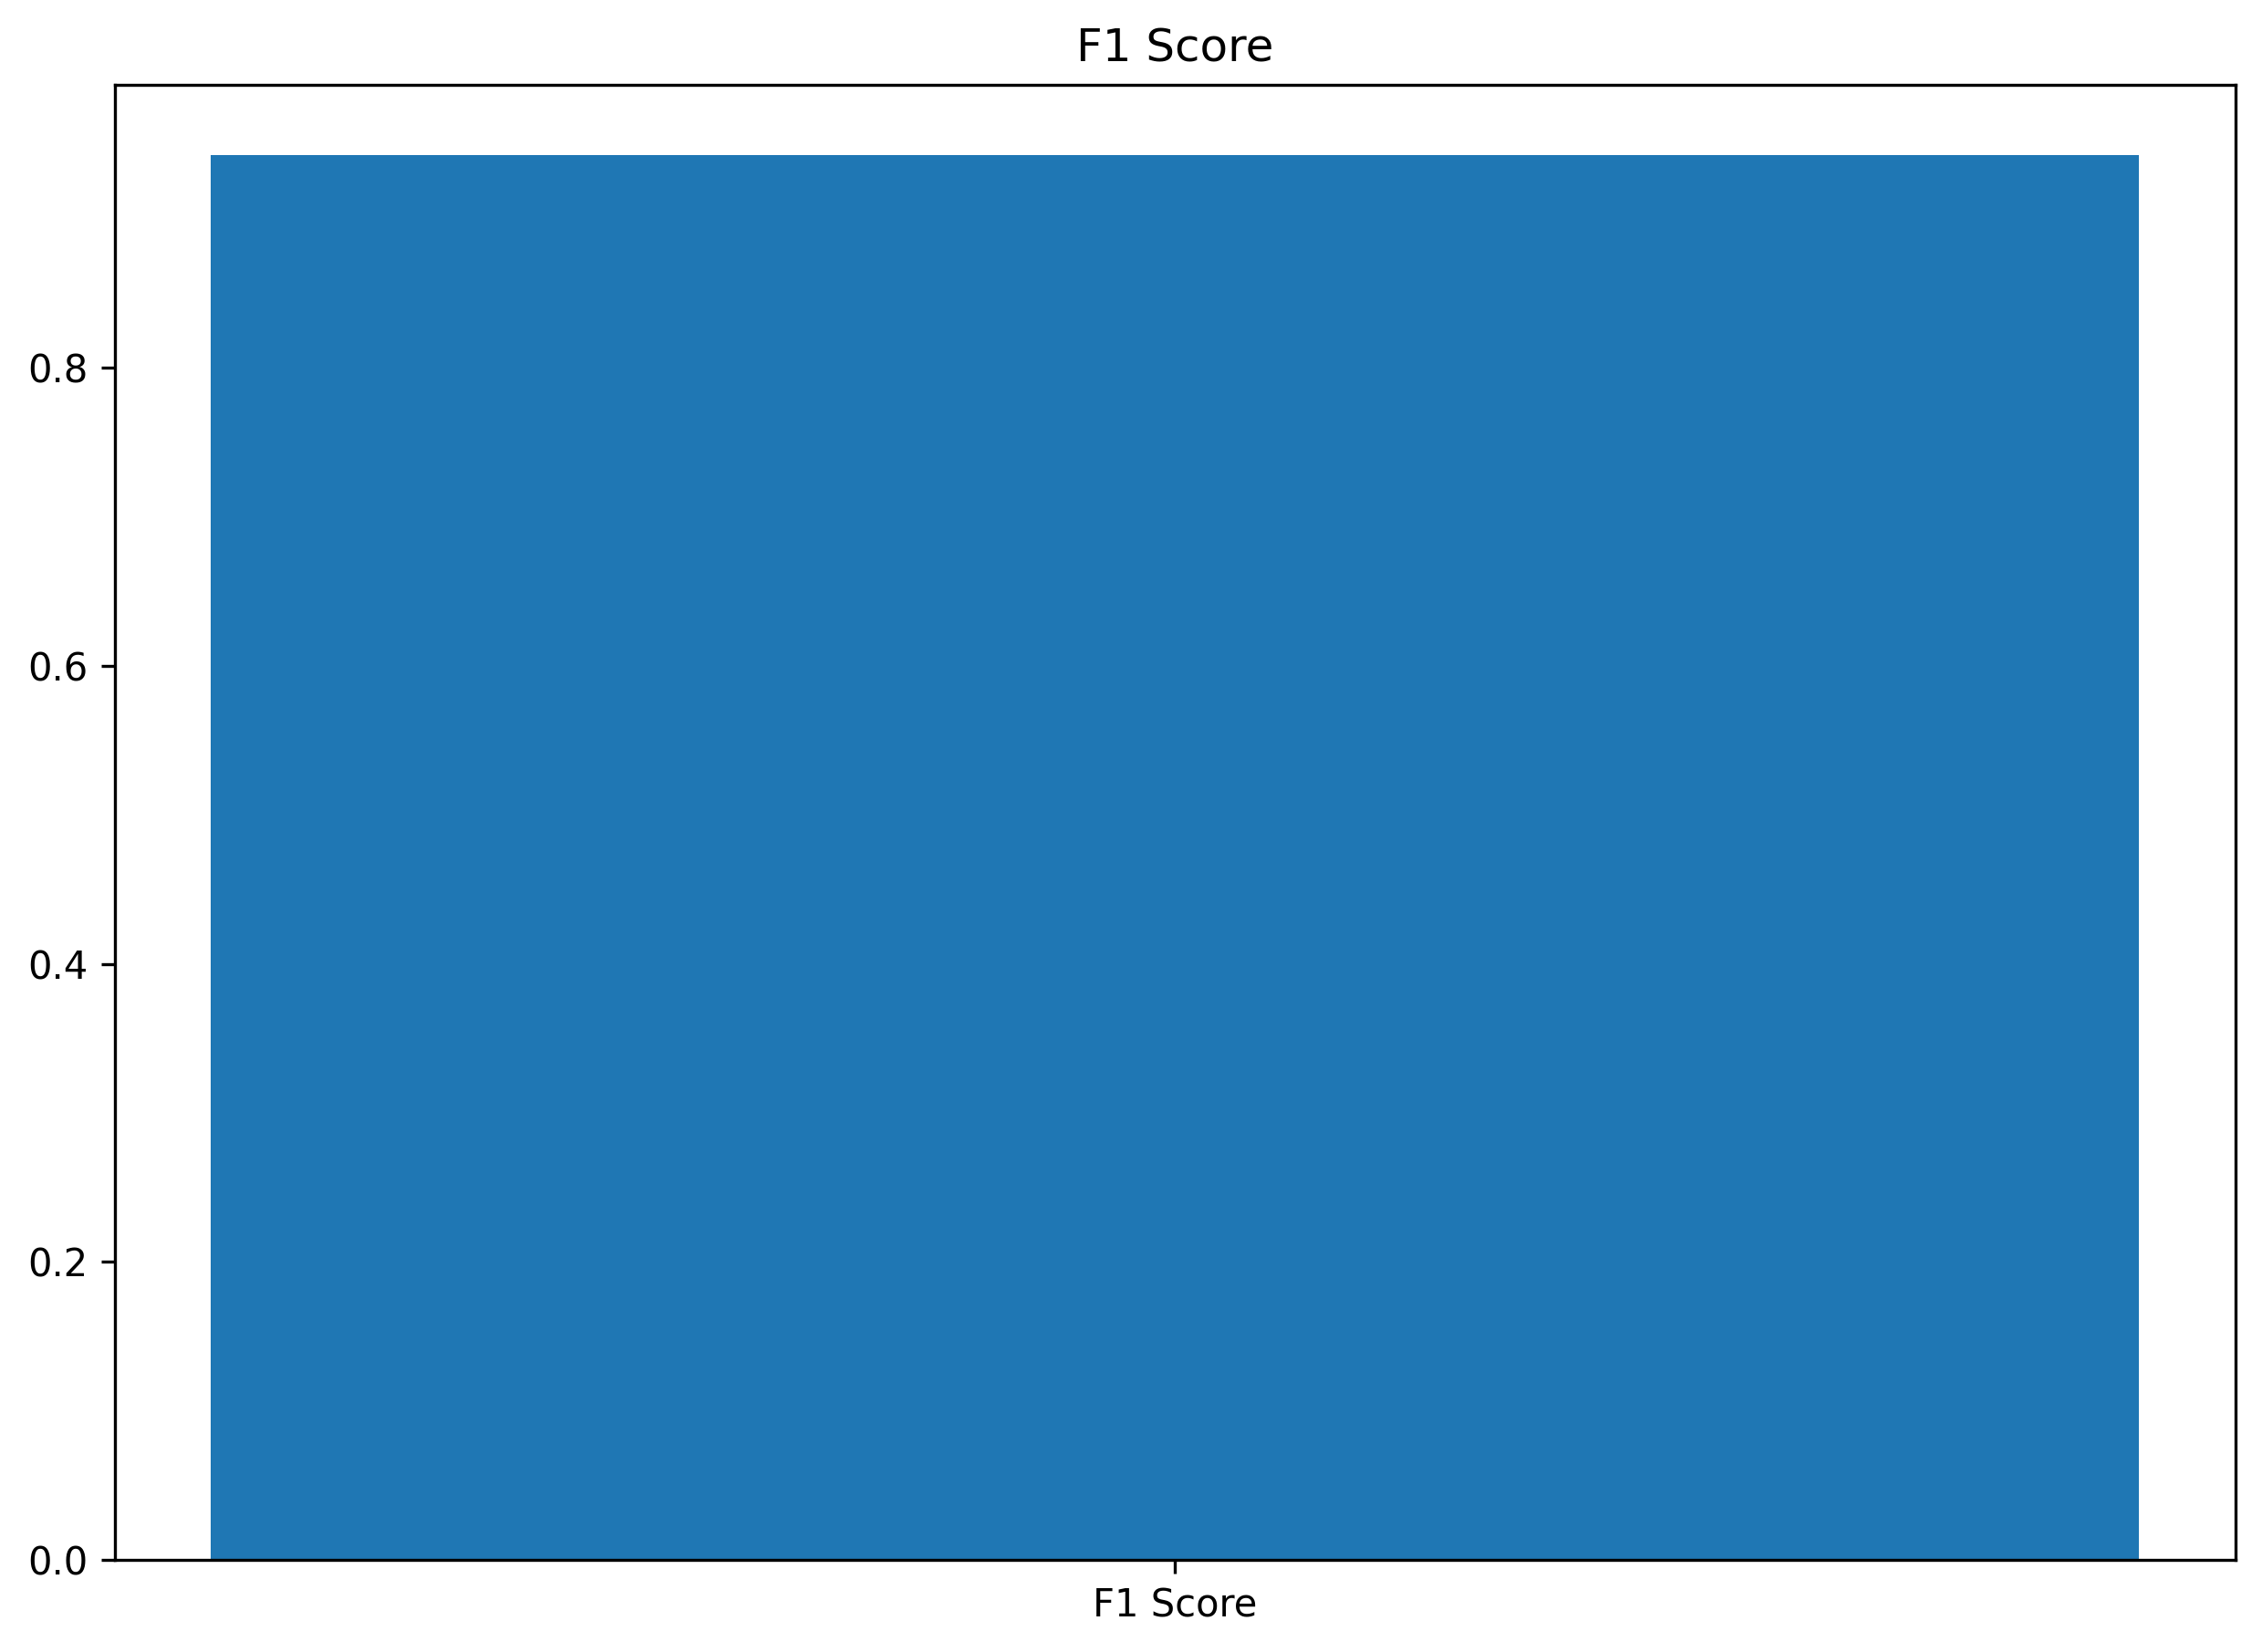

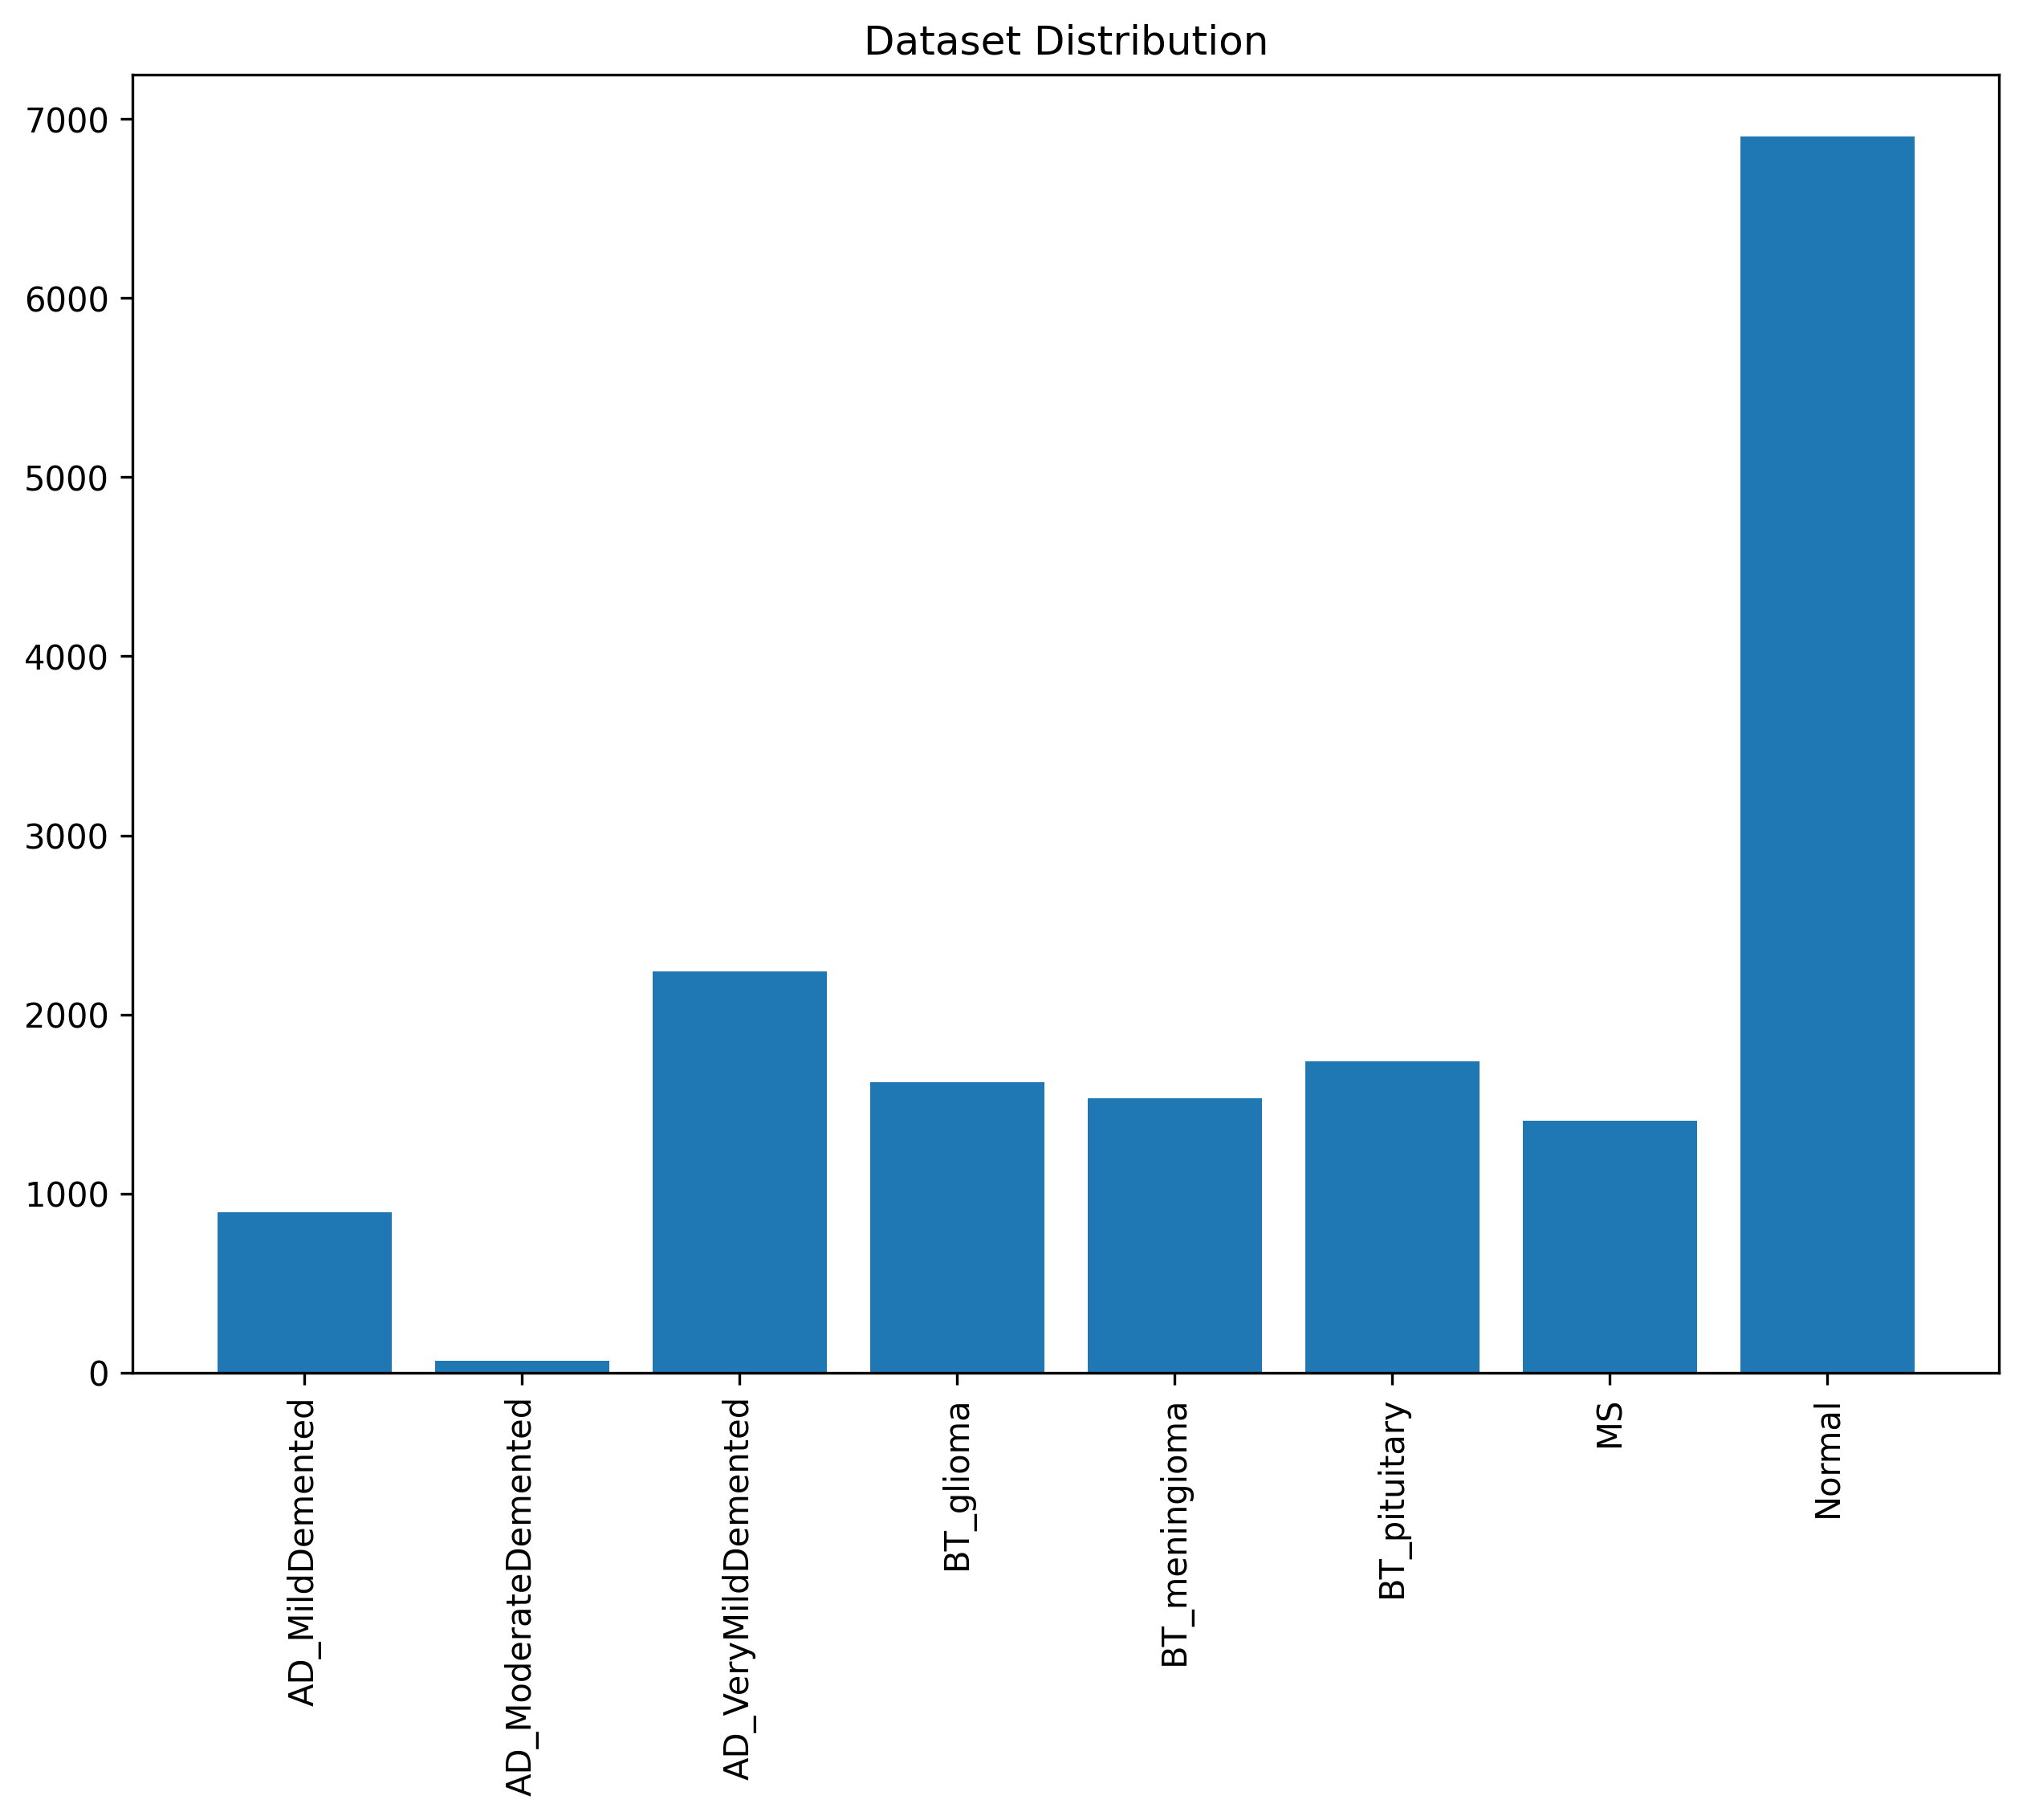

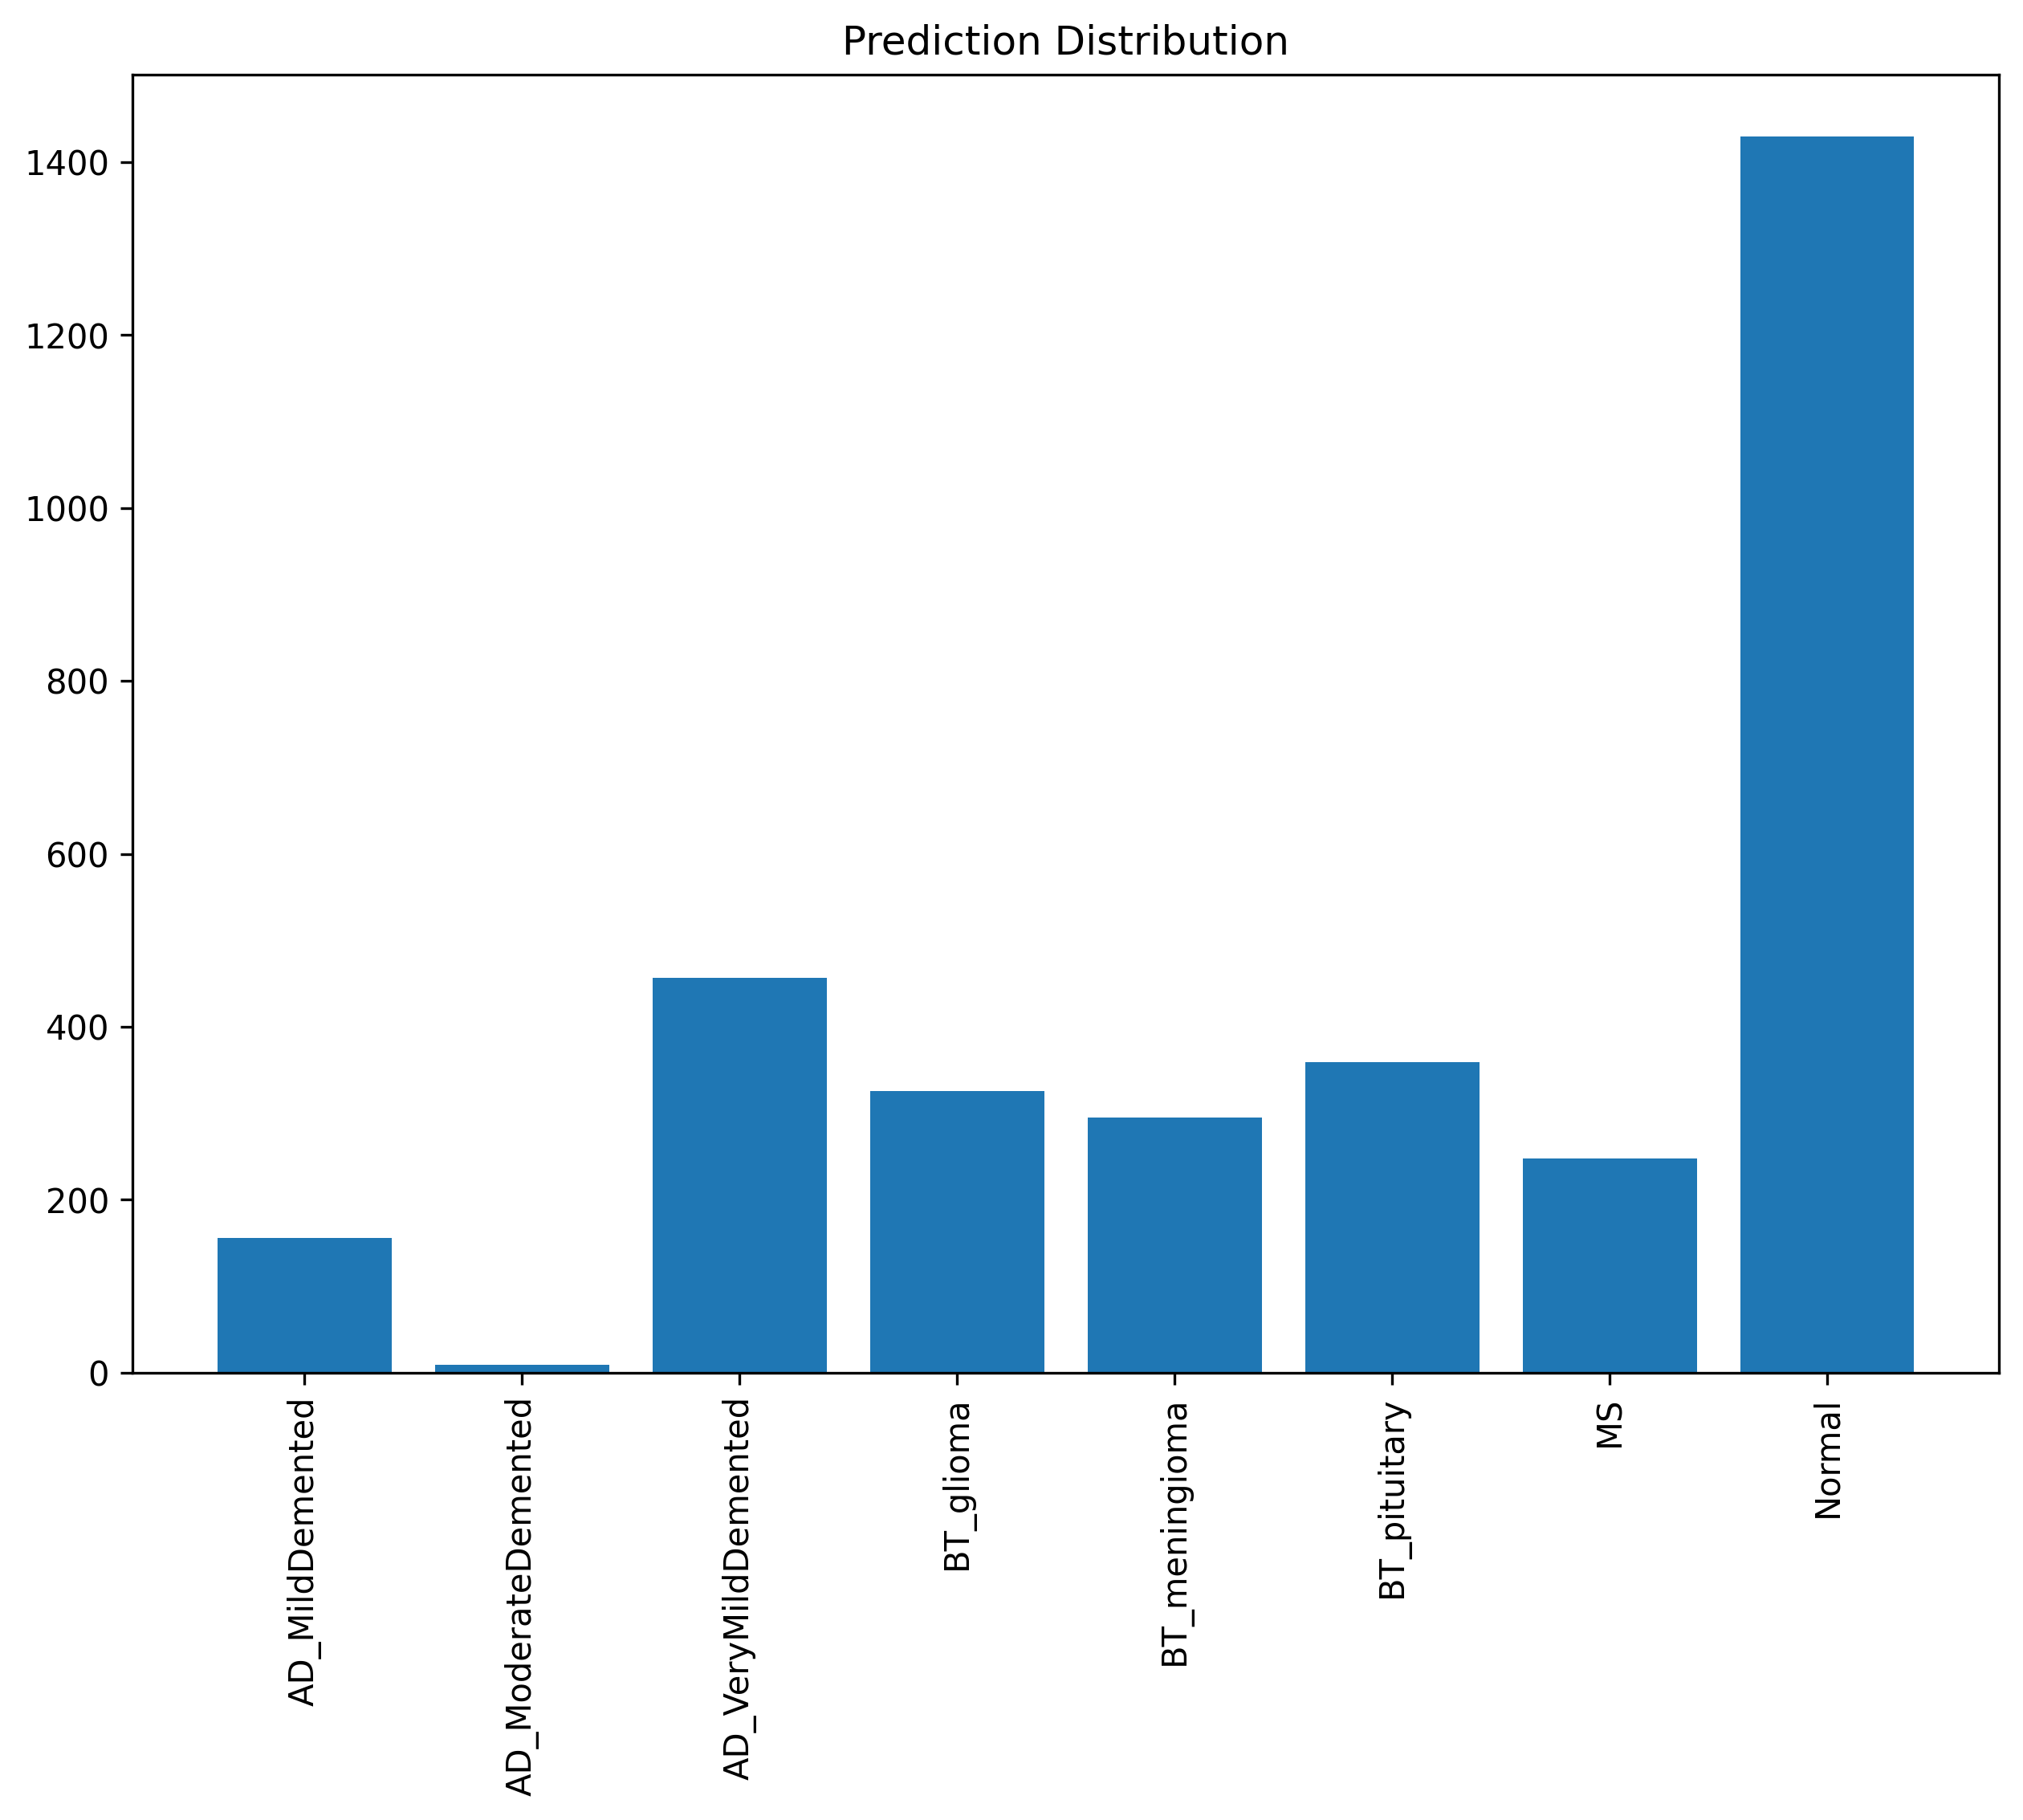

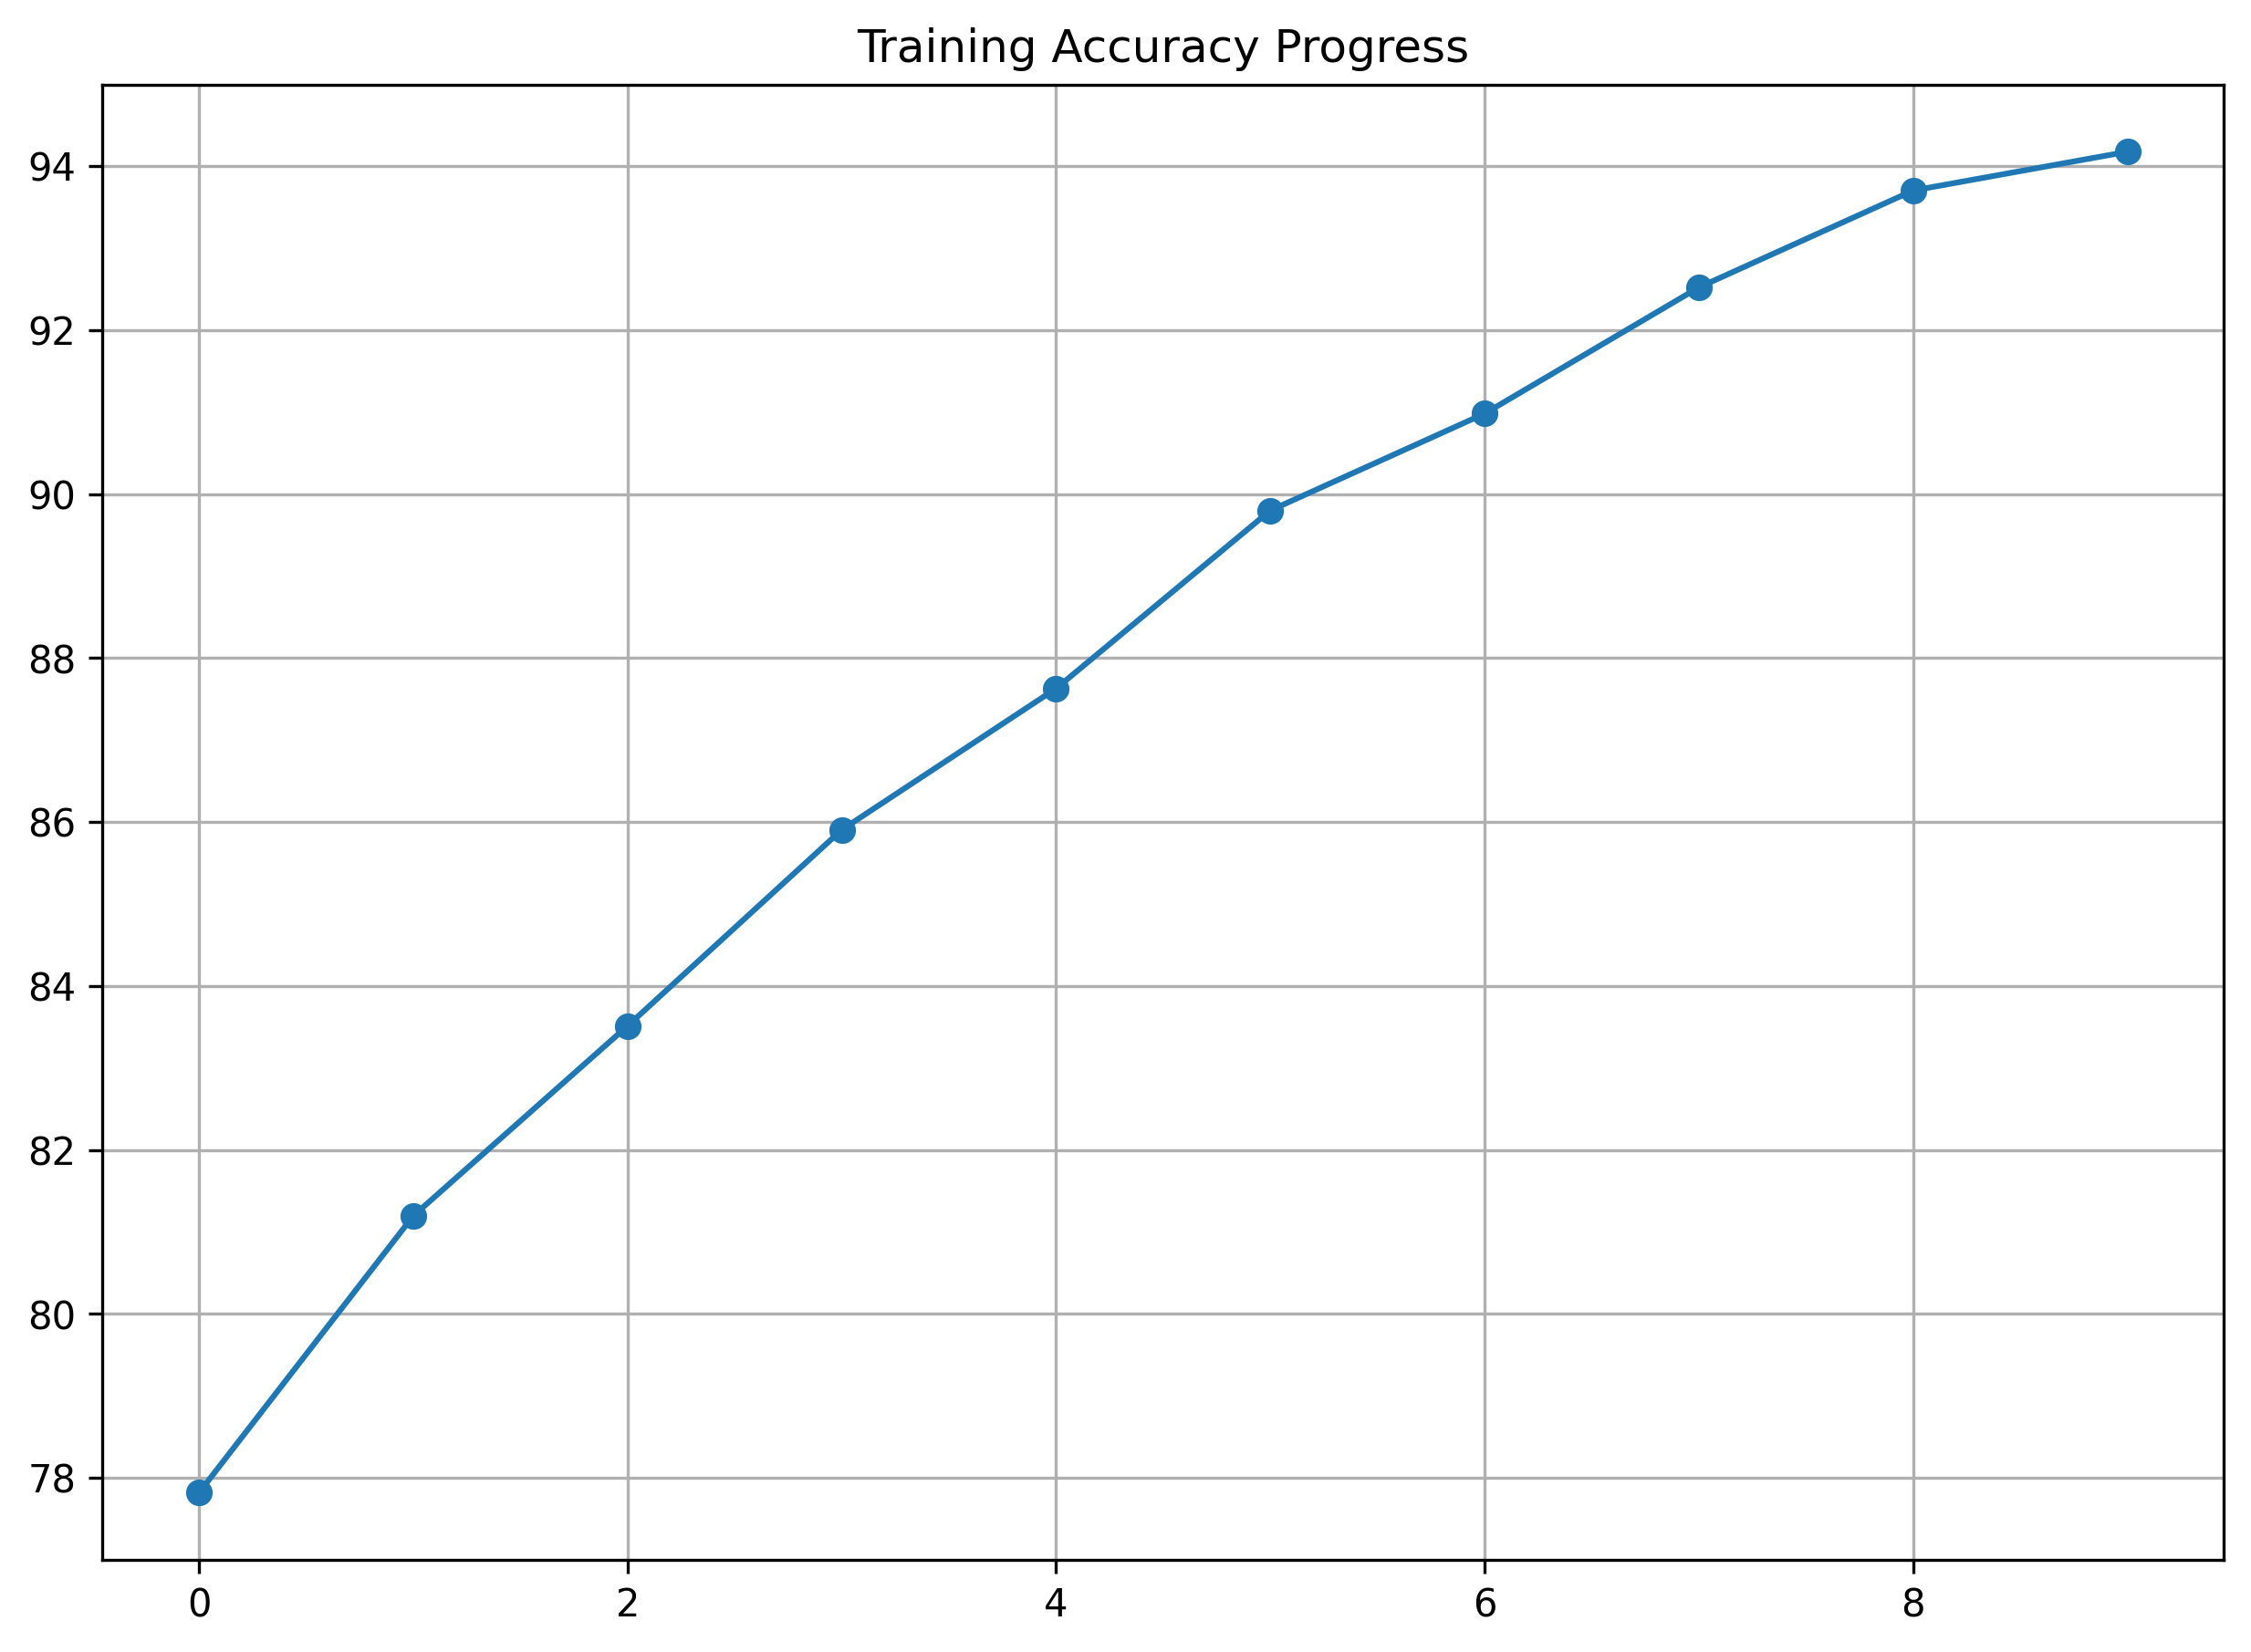

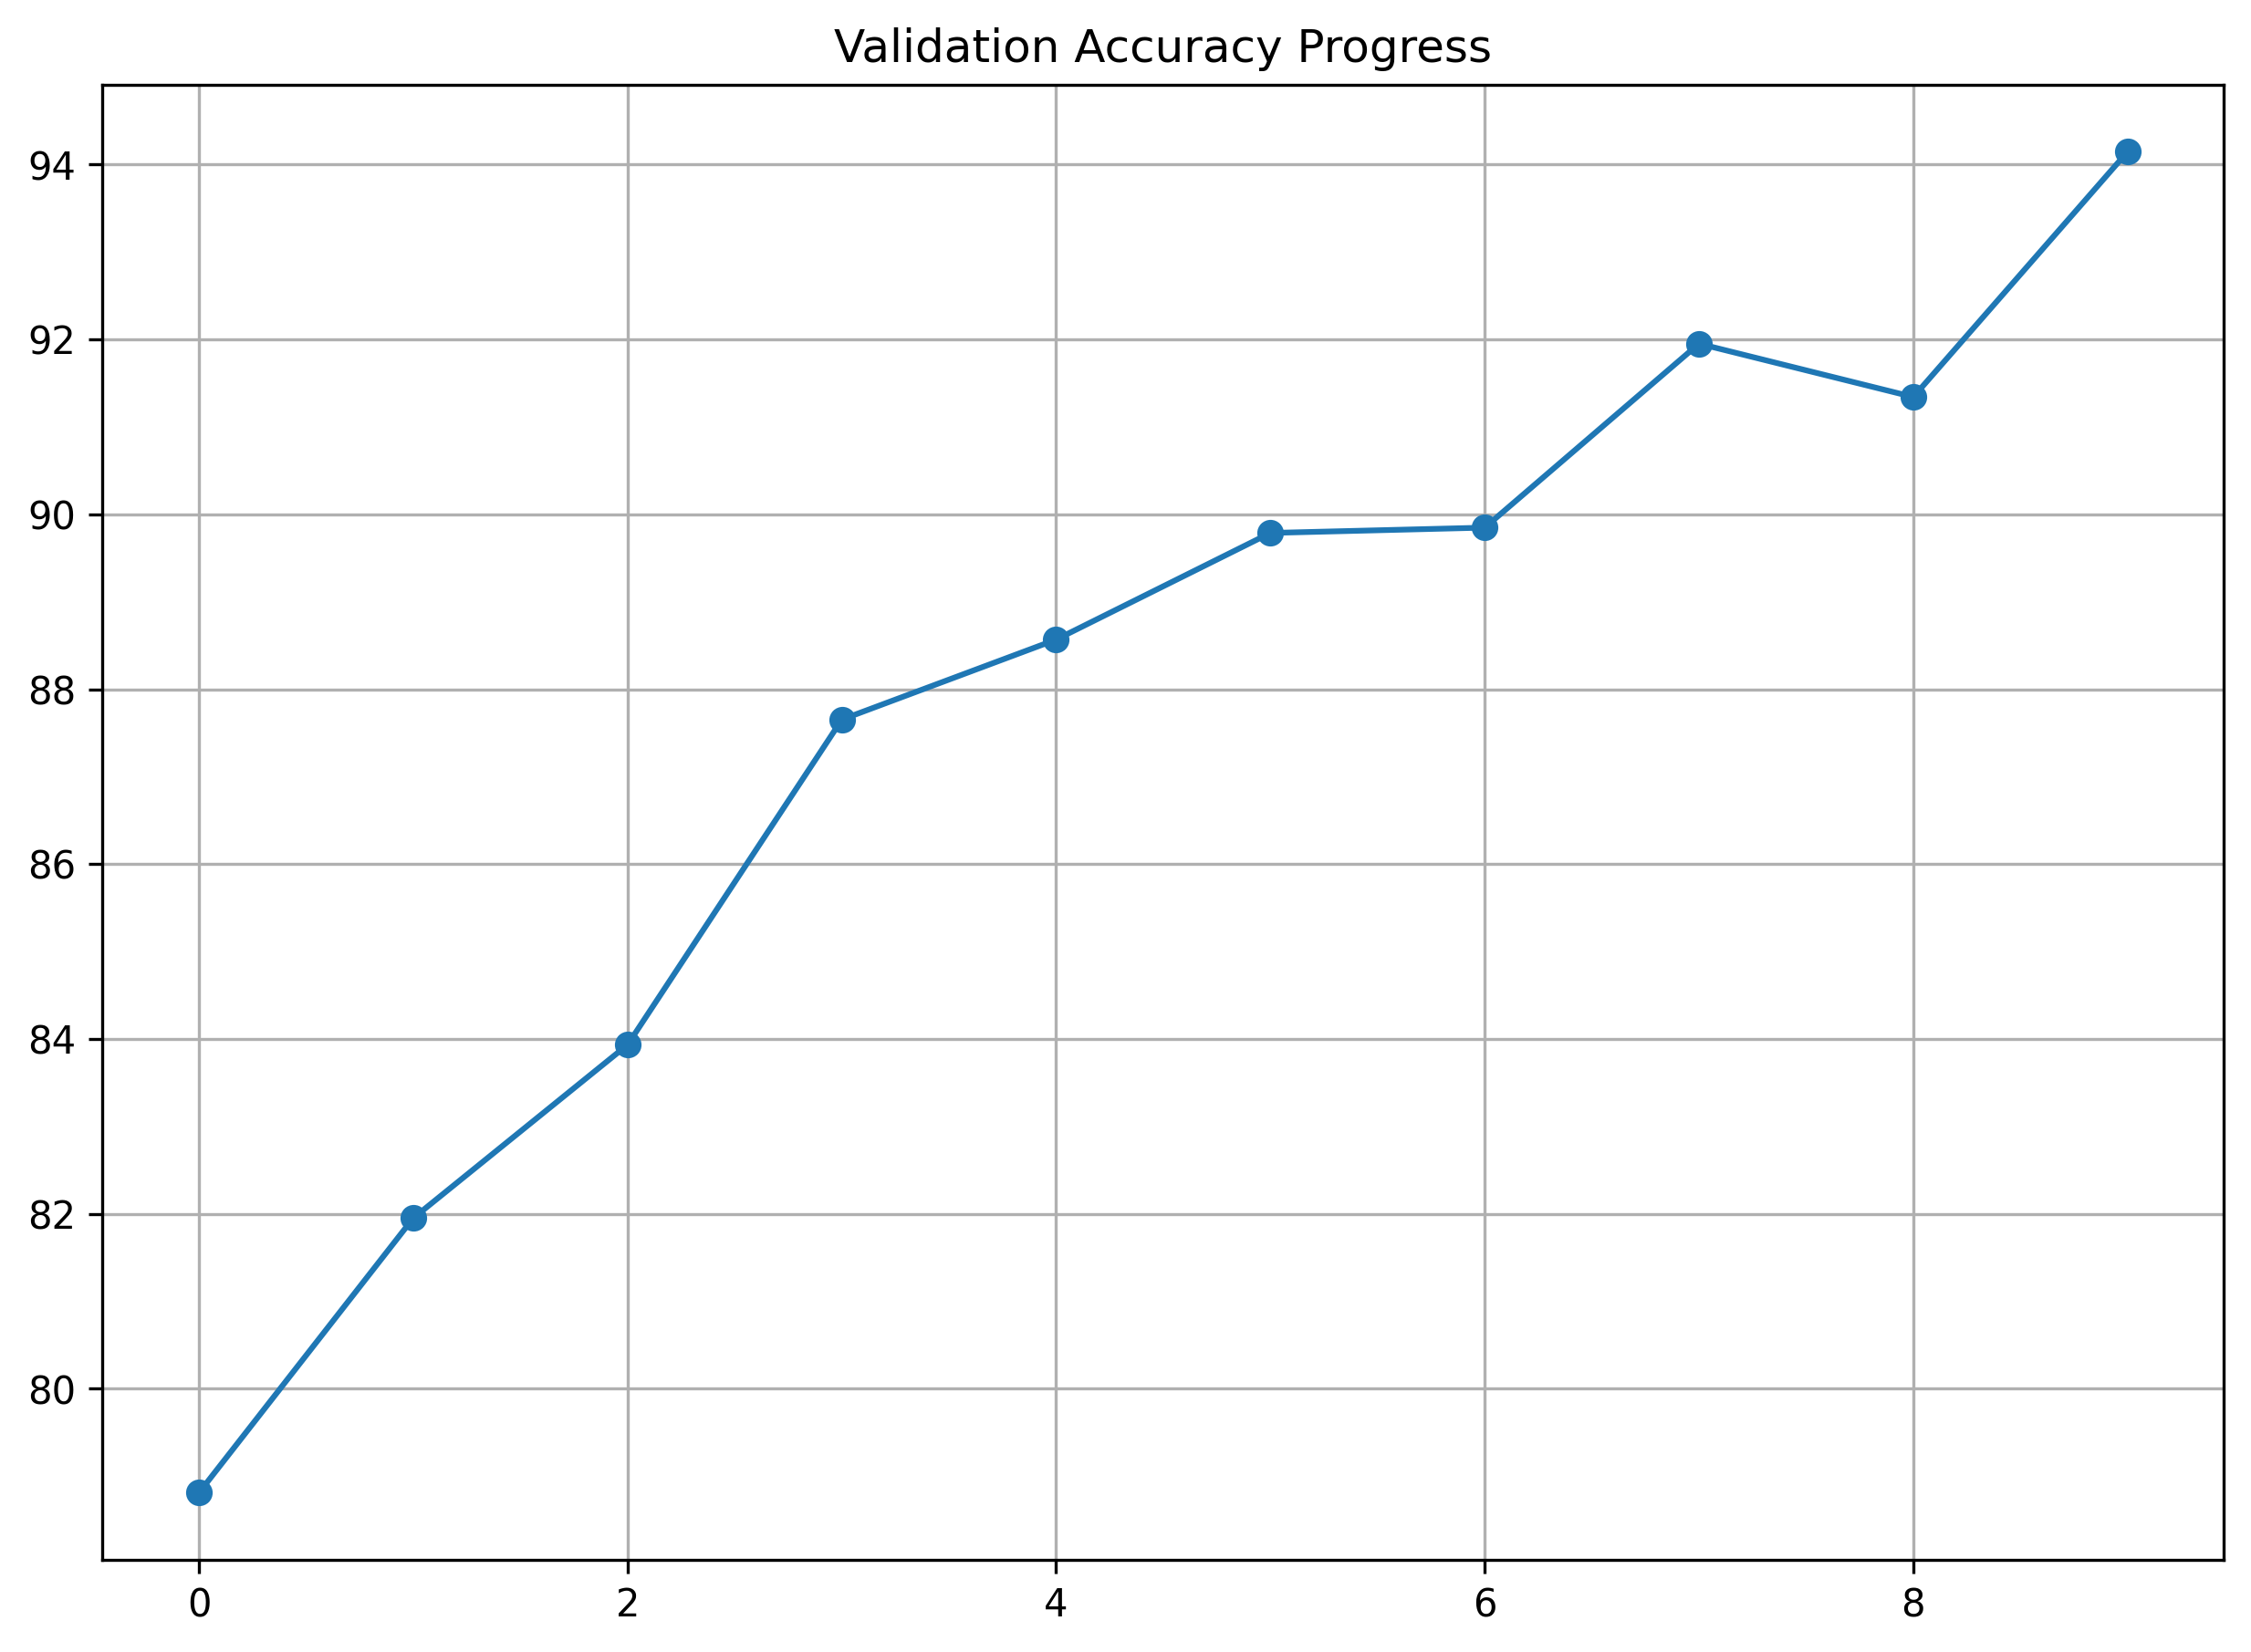

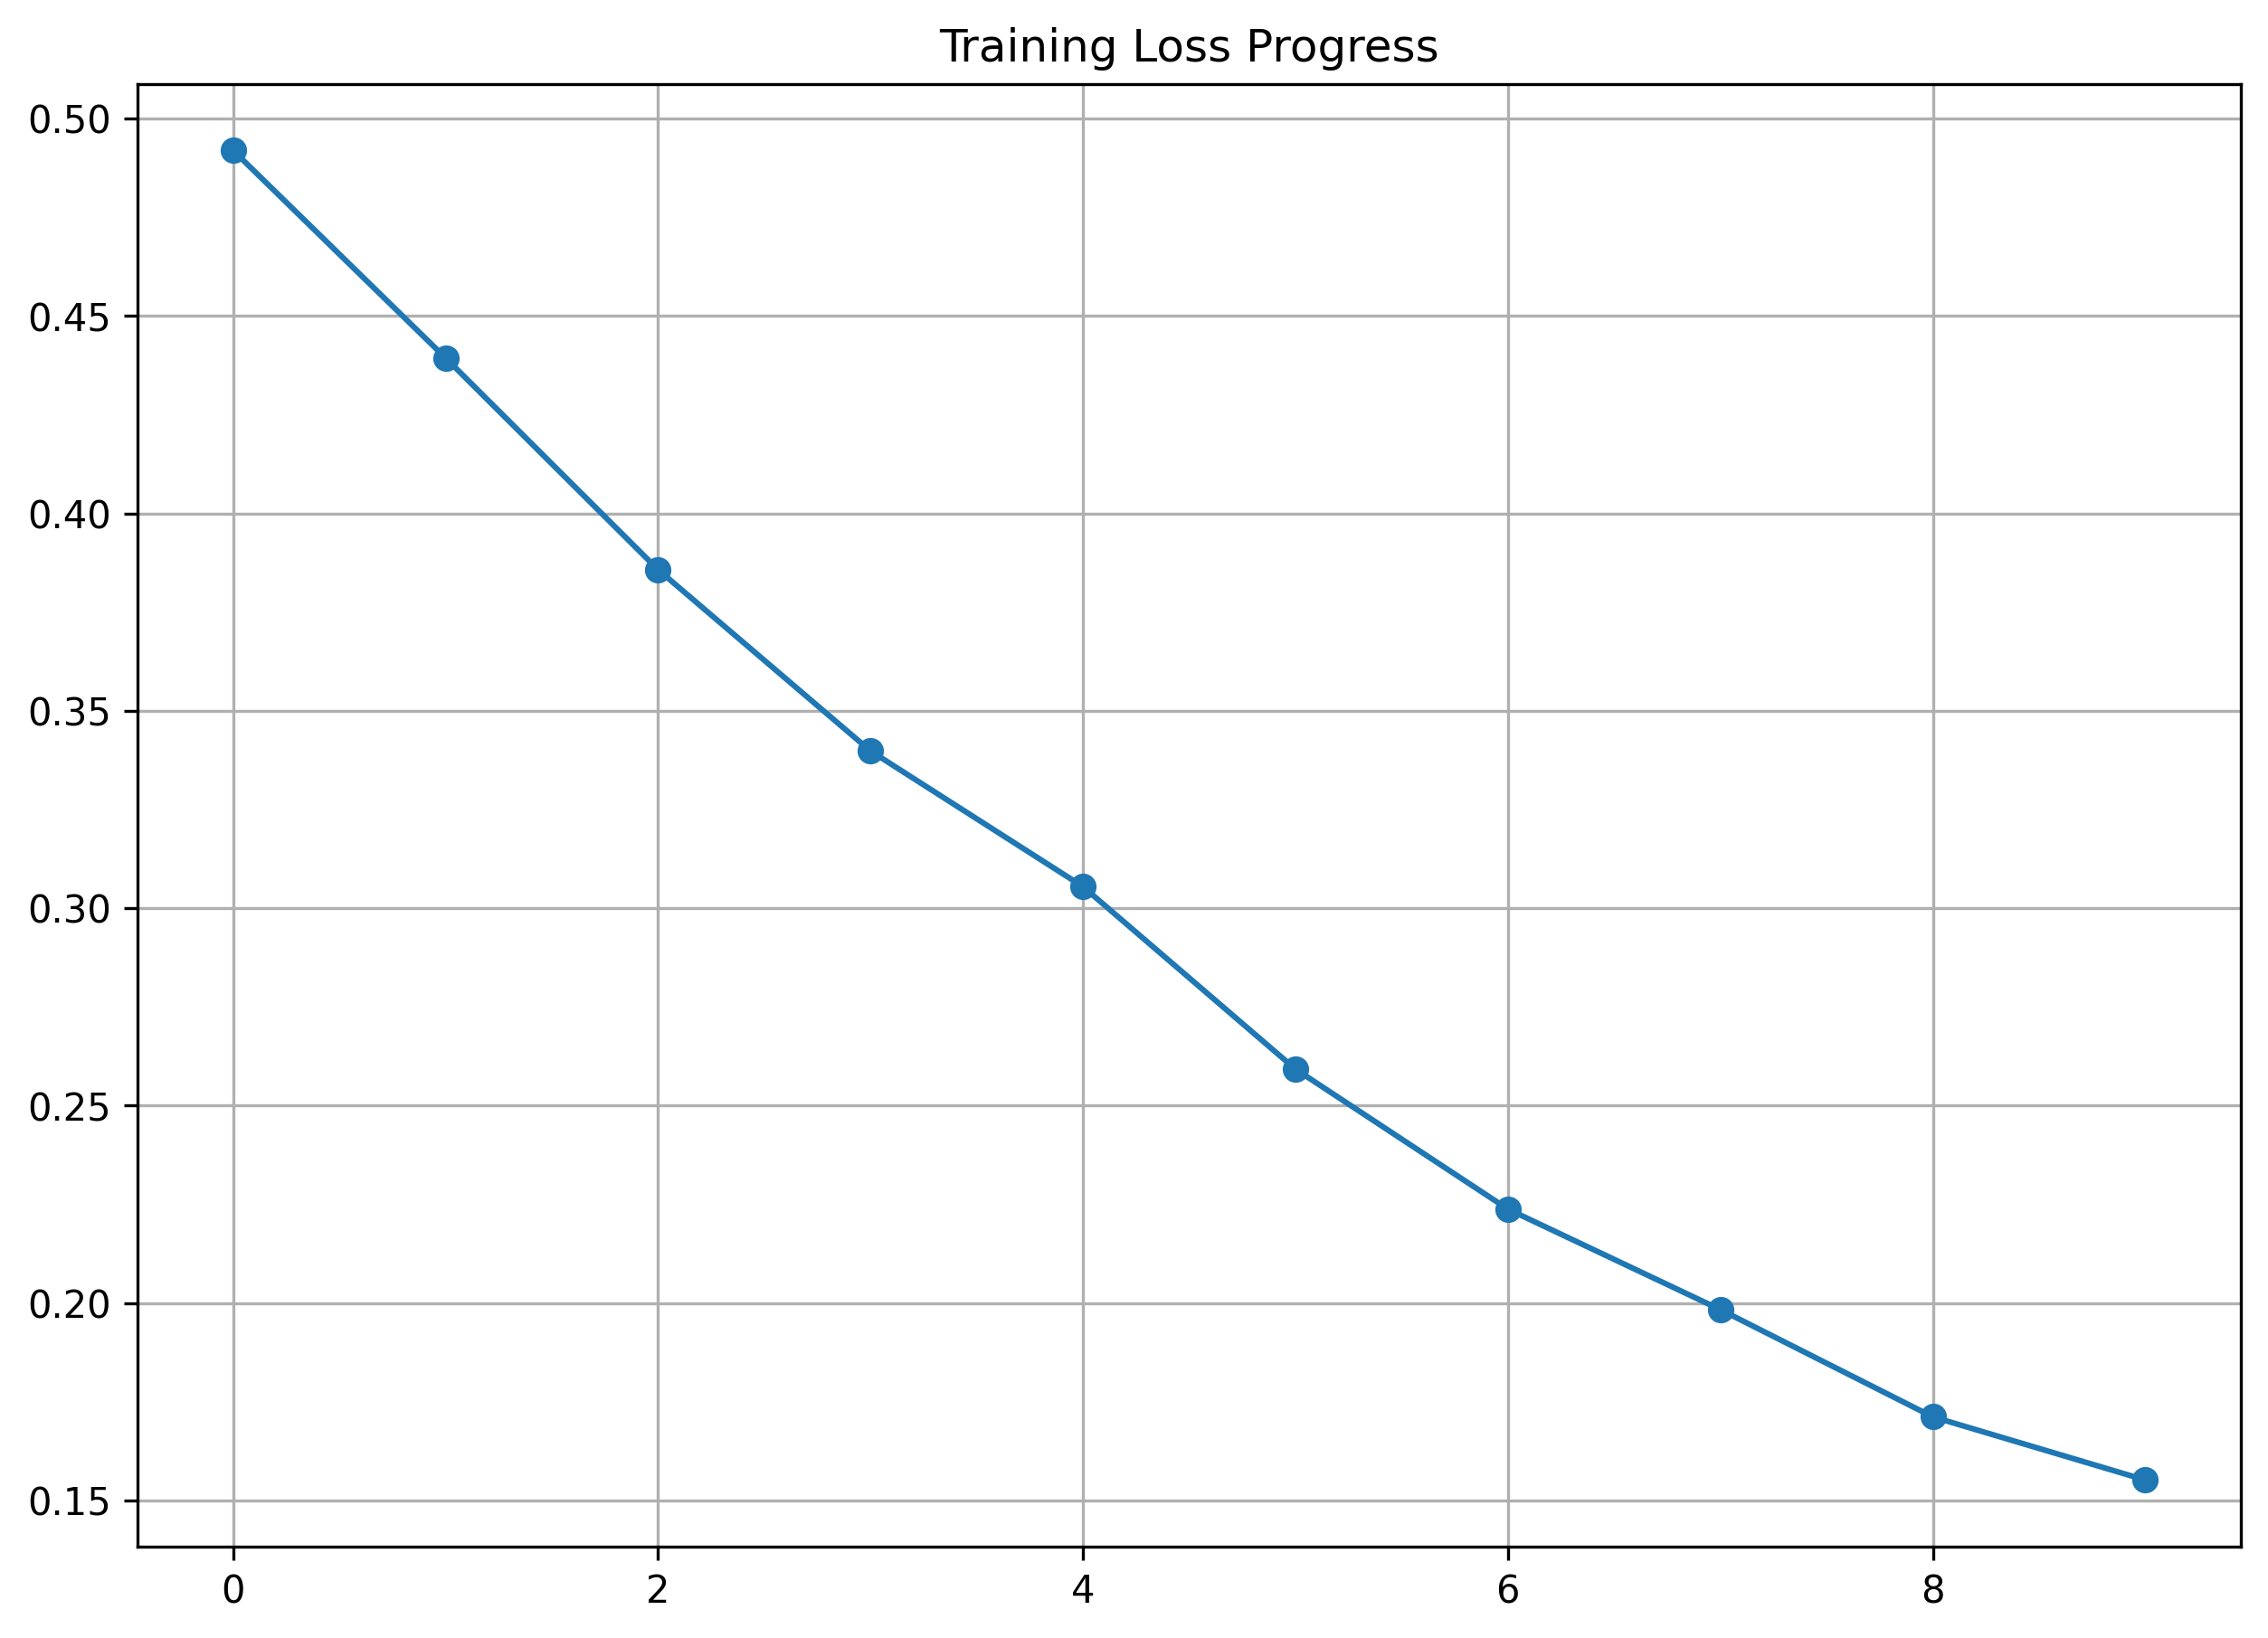

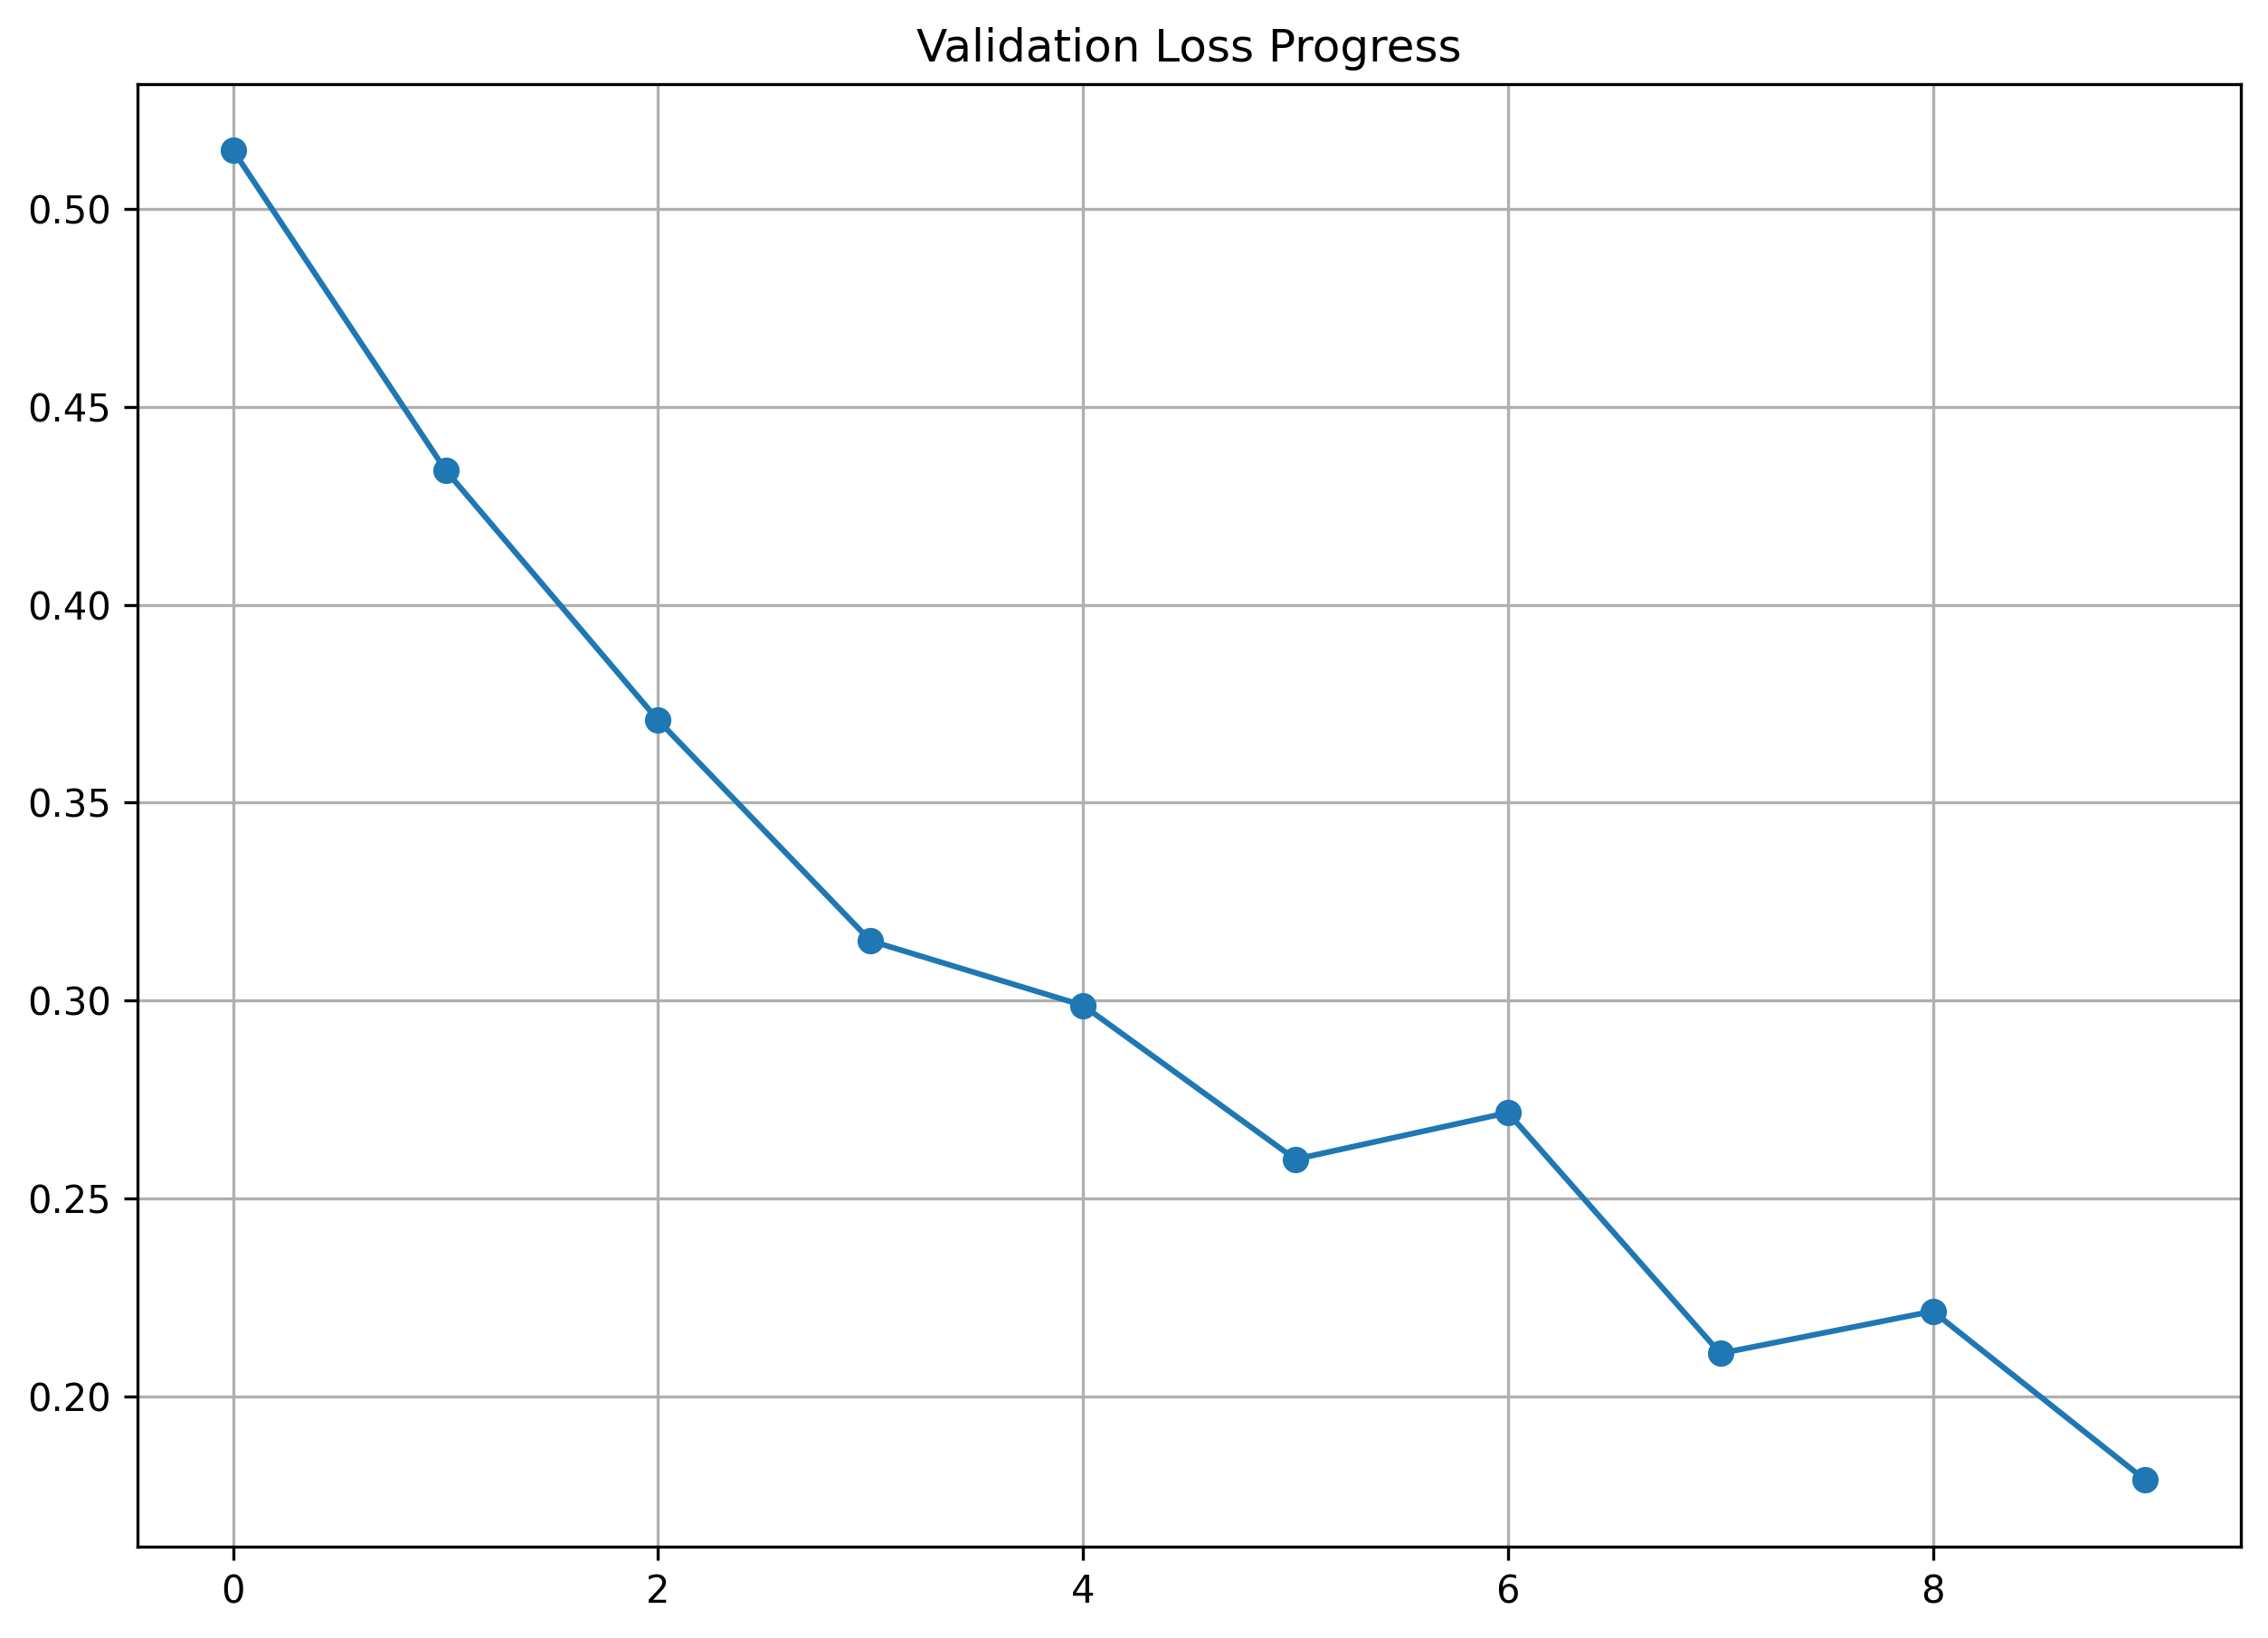


Classification Report:

                     precision    recall  f1-score   support

    AD_MildDemented       0.93      0.87      0.90       166
AD_ModerateDemented       1.00      1.00      1.00         9
AD_VeryMildDemented       0.89      0.88      0.89       460
          BT_glioma       0.99      0.98      0.98       330
      BT_meningioma       0.98      0.96      0.97       301
       BT_pituitary       0.98      0.99      0.98       356
                 MS       0.99      0.83      0.90       295
             Normal       0.93      0.97      0.95      1363

           accuracy                           0.94      3280
          macro avg       0.96      0.94      0.95      3280
       weighted avg       0.94      0.94      0.94      3280


Total Execution Time: 107.98167560100555 Minutes


In [ ]:


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

# ============================================================
# ROC CURVE
# ============================================================

y_true_bin = label_binarize(y_true, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        np.array(y_prob)[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

# ============================================================
# CREATE 14 HD RESEARCH GRAPHS
# ============================================================

plt.rcParams['figure.figsize'] = (10, 7)

# 1 Accuracy Graph
plt.figure(dpi=300)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()

# 2 Loss Graph
plt.figure(dpi=300)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

# 3 Time Complexity
plt.figure(dpi=300)
plt.plot(epoch_time)
plt.xlabel("Epoch")
plt.ylabel("Time (Seconds)")
plt.title("Epoch Time Complexity")
plt.grid()
plt.show()

# 4 Confusion Matrix
plt.figure(figsize=(12,10), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5 ROC Curves
plt.figure(dpi=300)

for i in range(num_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'{class_names[i]} AUC={roc_auc[i]:.2f}'
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# 6 Precision
plt.figure(dpi=300)
plt.bar(['Precision'], [precision])
plt.title("Precision Score")
plt.show()

# 7 Recall
plt.figure(dpi=300)
plt.bar(['Recall'], [recall])
plt.title("Recall Score")
plt.show()

# 8 F1 Score
plt.figure(dpi=300)
plt.bar(['F1 Score'], [f1])
plt.title("F1 Score")
plt.show()

# 9 Dataset Distribution
labels_count = [0]*num_classes

for _, label in dataset:
    labels_count[label] += 1

plt.figure(dpi=300)
plt.bar(class_names, labels_count)
plt.xticks(rotation=90)
plt.title("Dataset Distribution")
plt.show()

# 10 Prediction Distribution
pred_count = np.bincount(y_pred)

plt.figure(dpi=300)
plt.bar(class_names, pred_count)
plt.xticks(rotation=90)
plt.title("Prediction Distribution")
plt.show()

# 11 Accuracy Comparison
plt.figure(dpi=300)
plt.plot(train_acc, marker='o')
plt.title("Training Accuracy Progress")
plt.grid()
plt.show()

# 12 Validation Accuracy Comparison
plt.figure(dpi=300)
plt.plot(val_acc, marker='o')
plt.title("Validation Accuracy Progress")
plt.grid()
plt.show()

# 13 Training Loss Comparison
plt.figure(dpi=300)
plt.plot(train_loss, marker='o')
plt.title("Training Loss Progress")
plt.grid()
plt.show()

# 14 Validation Loss Comparison
plt.figure(dpi=300)
plt.plot(val_loss, marker='o')
plt.title("Validation Loss Progress")
plt.grid()
plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

# ============================================================
# TOTAL EXECUTION TIME
# ============================================================

end_total = time.time()

print("\nTotal Execution Time:",
      (end_total - start_total)/60,
      "Minutes")